# __BELLABEAT CASE STUDY__

### __FOREWORD__

This analysis was done as part of a capstone project for the Google Data Analytics Professional Certificate taught in [Coursera][coursera-link]. The given task was to answer a business question through data analysis coupled with a presentation deck. The case study and datasets were intentionally omitted in my github page to respect existing copyright laws. Nevertheless, please feel free to request for them if you need these files for personal use.

This notebook can be found both in my [github][github-repo] page as well as my [kaggle][kaggle-notebook] repo/ notebook. I hope that my analysis augments the already existing scope and breath of other analyses by others.

[coursera-link]: https://www.coursera.org/professional-certificates/google-data-analytics
[github-repo]: https://github.com/lzytimx/Portfolio
[kaggle-notebook]: https://www.kaggle.com/lzytim/bellabeat-case-study-with-python

### __INTRODUCTION__
Bellabeat is a high-tech manufacturer of health-focused products for women. Bellabeat designs wearables to capture data and deliver health insights primarily to the women demographic. The wearable tracks various health-related data like sleep, heart rate, and respiration. The collected data is processed and transformed into actionable health insights delivered through the Bellabeat app. To date, Bellabeat has provided information and actionable health insights that cover domains including (i) reproductive health, (ii) sleep, (iii) readiness, (iv) stress resistance, and (v) pregnancy.


### __BUSINESS TASK__
Urška Sršen, the Chief Creative Officer of Bellabeat, have requested for you to focus on Bellabeat's products and analyse smart device data to gain insight into how consumers are using their smart devices. She then wants you to select one Bellabeat product to apply these insights in our presentation. __These insights will help guide marketing strategy for the company.__ You will present your analyss to the Bellabeat executive team along with your high-level recommendation for Bellabeat's marketing strategy. These questions will guide your analyses:

- What are some trends in smart device usage?
- How could these trends apply to Bellabeat customers?
- How could these trends help influence Bellabeat marketing strategy?


### __STAKEHOLDERS__
- __Urška Sršen__: Bellabeat's co-founder and Chief Creative Officer
- __Sando Mur__: Mathematician and Bellabeat's co-founder, key member of the Bellabeat executive team
- __Marketing Analytics Team__: A team of analysts responsible for collecting, analysing, and reporting data that helps guide Bellabeat's marketing strategy.


### __DATA__
The [dataset][fitbit_dataset] used for this analysis is the FitBit Fitness Tracker Data and it was made available through Mobius on Kaggle (CC0: Public Domain). This Kaggle data set was created between 03.12.2016-05.12.2016 and contains personal fitness tracker from thirty fitbit users. Thirty eligible Fitbit users consented to the submission of personal tracker data, including minute-level output for physical activity, heart rate, and sleep monitoring. It includes information about daily activity, steps, and heart rate that can be used to explore users’ habits.

[fitbit_dataset]: https://www.kaggle.com/datasets/arashnic/fitbit


### __REFERENCES__
- Macarena Lacasa: [Capstone - Case Study Bellabeat][macarenalacasa_bellabeat]
- Joy Okwu: [Bellabeat Case Study With R][joyokwu_bellabeat]


[macarenalacasa_bellabeat]: https://www.kaggle.com/code/macarenalacasa/capstone-case-study-bellabeat/notebook
[joyokwu_bellabeat]: https://www.kaggle.com/code/joyokwu/bellabeat-case-study-with-r

# __DATA ANALYSIS LIFE CYCLE__

### ASK
- Urška Sršen, the Chief Creative Officer of Bellabeat, has requested for us to analyse public smart devices data to uncover insights into how consumers are using their smart devices. Insights found will then guide the marketing strategy for the company.
- There are 3 main stakeholders, the Mur, Sršen, and the marketing analytics team 
### PREPARE
- Data is retrieved online through Kaggle under a Creative Commons (Public Domain) License. This is considered a third-part dataset since it is derived externally.
- Analysis done showed some inconsistencies between the description of data and what was actually found in the dataset. The dataset claims that there were 30 participants with 2 months of longitudinal data. However, we found that there were 33 participants with 1 month of logitudinal data. The discrepany of the data compromises the credibility of the data.
- Furthermore, 33 (or 30) participants is too small a dataset. Findings in this dataset might not reflect trends of the population (i.e. people who wear smart devices). To add to this complexity, our target population is those that we want to sell our wearable devices to. So our target population and our intended customers are already discordant in the first instance.
- Our marketing strategy has to take into account that prospective buyers of our smart devices do not understand our product, and we also need to market the features of the product.
### PROCESS
- Nulls and Duplicates had been found and dealt with. The analysis is traceable and stored within this jupyter notebook.
- The tool of choice for analysis is Python with its various packages. Seaborn is used in this analysis as th primary choice for data visualisation
### ANALYSE
- Five Domains of data covering Steps, Sleep, Distance, Activities, and Calories were analysed.
- Domains that were continually tracked, such as steps, distance, and calories had more comprehensive data. On the other hand, domains that require manual activation for tracking, such as activities and sleep, had significant gaps in data. 
- There were two broad groups of customer archetypes using smart devices. The first group are religious in using their smart device, and tend to log as much information as they can under the 5 domains of tracked data. On the other hand, the second group are those do either did not track, or did not even wear their smart devices. 
### SHARE
- Visualisations created and additional findings can be found in Section 1.4 of this notebook.
- Key findings can be found under the Analyse header.
### ACT
- The marketing strategy have to include reasons why customers should buy our wearables and use our app in their marketing messaging. On top of the 5 domains of steps, sleep, distance, activities, and calories, repoductive health and pregnancy tracking are some ways that the Bellabeat team pursues its unique sellling point as choice smart device for women.
- The marketing team should also explain how data can be used to inform the wearer about insights to their current health condition, and suggest ways to improve their personal and mental well-being

# __DATA ANALYSIS__

### 1.1 Importing libraries

In [387]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
# import datetime
# import operator
# from matplotlib.colors import BoundaryNorm

In [172]:
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

I have done some preliminary EDA and found that using the daily dataset would suffice in observing trends for smart device usage. So our analysis will focus on the daily datasets

In [173]:
folder = './dataset/'
daily_filenames = [folder + i for i in os.listdir(folder) if 'daily' in i.lower() or 'day' in i.lower()]
# filenames = [folder + i for i in os.listdir(folder)]
for index, name in enumerate(daily_filenames):
    print(index, name)

0 ./dataset/dailyActivity_merged.csv
1 ./dataset/sleepDay_merged.csv
2 ./dataset/dailyCalories_merged.csv
3 ./dataset/dailySteps_merged.csv
4 ./dataset/dailyIntensities_merged.csv


### 1.2 Merging Datasets

In [349]:
# Importing the acitivity dataset
activity = pd.read_csv(daily_filenames[0], parse_dates=['ActivityDate'])

# Importing the sleep dataset
sleep = pd.read_csv(daily_filenames[1])
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'], format='%m/%d/%Y %I:%M:%S %p')
sleep.rename(columns={'SleepDay':'ActivityDate'}, inplace=True)

# Importing the calories dataset
calories = pd.read_csv(daily_filenames[2], parse_dates=['ActivityDay'])
calories.rename(columns={'ActivityDay':'ActivityDate'}, inplace=True)

# Importing steps dataset
steps = pd.read_csv(daily_filenames[3], parse_dates=['ActivityDay'])
steps.rename(columns={'ActivityDay':'ActivityDate', 'StepTotal':'TotalSteps'}, inplace=True)

# Importing intensity dataset
intensity = pd.read_csv(daily_filenames[4], parse_dates=['ActivityDay'])
intensity.rename(columns={'ActivityDay':'ActivityDate'}, inplace=True)

print(activity.shape, sleep.shape, calories.shape, steps.shape, intensity.shape)

(940, 15) (413, 5) (940, 3) (940, 3) (940, 10)


Interestingly, the first (activity), third (calories), fourth (steps), and fifth (intensity) dataset has the same number of rows in their respective dataframes. The columns from the activity dataset also contains similar row names found in the latter three datasets. We should investigate if the latter 3 datasets are subsets of the first dataset

In [350]:
# Check if the column names in the calories dataframe can be found in the activity dataframe
calories_col = calories.columns

# Here, I am getting the index of the columns that appear in the calories dataframe so that I can slice the activity dataframe
calories_col_loc = [activity.columns.get_loc(i) for i in calories_col]
activity_part = activity.iloc[:, calories_col_loc]

# If all elements of the row are the same, the output for each row will return true. Next, I summed up all the boolean values.
# If the sum of the booleans equal to the number of records in the activity dataframe, then the calories dataframe is indeed a subset of the activity dataframe
print((calories == activity_part).all(axis=1).sum() == activity.shape[0])



# Check if the steps dataframe is a subset of the activity dataframe
steps_col = steps.columns
steps_col_loc = [activity.columns.get_loc(i) for i in steps_col]
activity_part = activity.iloc[:, steps_col_loc]
print((steps == activity_part).all(axis=1).sum() == activity.shape[0])

# Check if the intensity dataframe is a subset of the activity dataframe
intensity_col = intensity.columns
intensity_col_loc = [activity.columns.get_loc(i) for i in intensity_col]
activity_part = activity.iloc[:, intensity_col_loc]
print((intensity == activity_part).all(axis=1).sum() == activity.shape[0])

True
True
True


We found that the steps, intensity, and calories datasets are all subsets of the bigger activity dataframe, therefore it is sufficient to omit the former 3 datasets and concentrate on analysing the activity and sleep dataframes. We will also perform the additional step of merging the sleep and activity dataframes

In [351]:
comb_df = activity.merge(sleep, how='outer', on=['Id', 'ActivityDate'])
comb_df

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162,8.500000,8.500000,0.0,1.88,0.55,6.06,0.00,25,13,328,728,1985,1.0,327.0,346.0
1,1503960366,2016-04-13,10735,6.970000,6.970000,0.0,1.57,0.69,4.71,0.00,21,19,217,776,1797,2.0,384.0,407.0
2,1503960366,2016-04-14,10460,6.740000,6.740000,0.0,2.44,0.40,3.91,0.00,30,11,181,1218,1776,NaN,NaN,NaN
3,1503960366,2016-04-15,9762,6.280000,6.280000,0.0,2.14,1.26,2.83,0.00,29,34,209,726,1745,1.0,412.0,442.0
4,1503960366,2016-04-16,12669,8.160000,8.160000,0.0,2.71,0.41,5.04,0.00,36,10,221,773,1863,2.0,340.0,367.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,8877689391,2016-05-08,10686,8.110000,8.110000,0.0,1.08,0.20,6.80,0.00,17,4,245,1174,2847,NaN,NaN,NaN
939,8877689391,2016-05-09,20226,18.250000,18.250000,0.0,11.10,0.80,6.24,0.05,73,19,217,1131,3710,NaN,NaN,NaN
940,8877689391,2016-05-10,10733,8.150000,8.150000,0.0,1.35,0.46,6.28,0.00,18,11,224,1187,2832,NaN,NaN,NaN
941,8877689391,2016-05-11,21420,19.559999,19.559999,0.0,13.22,0.41,5.89,0.00,88,12,213,1127,3832,NaN,NaN,NaN


The dataset has been combined. We can now proceed with exploring the dataset with the `comb_df` dataframe

In [365]:
print(comb_df['Id'].nunique())
print(comb_df['ActivityDate'].nunique())

33
31


### 1.3 Checking for Duplicates, Nulls, and Broad Metadata Information about the Dataset
General Comments about the dataset:
- The [dataset][fitbit_dataset] claims that there are 30 participants over a two-month period, but what we have found is that there are <ins>__33__</ins> participants in this dataset over only a <ins>__one-month__</ins> period. The discrepancy of the description of the dataset compared to what is actually in the dataset the credibility of the dataset
- Further digging into other datasets needs to be performed to verify if the description of the dataset fits what is actually in the dataset

[fitbit_dataset]: https://www.kaggle.com/datasets/arashnic/fitbit

In [373]:
shape = comb_df.shape
duplicates = comb_df.duplicated().sum()
nulls = comb_df.isnull().sum().sum()
unique_id = comb_df['Id'].nunique()
unique_dates = comb_df['ActivityDate'].nunique()

print(f'Shape of the datafrae: rows: {shape[0]}, columns: {shape[1]}')
print(f'Number of duplicates in the dataframe: {duplicates}')
print(f'Number of nulls in the dataframe: {nulls}')
print(f'Unique participants in the dataframe: {unique_id}')
print(f'Unique dates in the dataframe: {unique_dates}')

Shape of the datafrae: rows: 943, columns: 18
Number of duplicates in the dataframe: 3
Number of nulls in the dataframe: 1590
Unique participants in the dataframe: 33
Unique dates in the dataframe: 31


We should expect an increase in the number of null values, since we had performed an outer join between the activity and sleep datasets. A prior analysis showed that there are 3 duplicates in the sleep dataset, which has been transferred into the combined dataset. Therefore, we should remove the duplicates to avoid instances of double counting in our analysis

In [ ]:
df = comb_df.drop_duplicates().copy()

In [375]:
df.shape

(940, 18)

### 1.4 Exploratory Data Analysis

#### 1.4.1 Steps

##### Q1: Do people use their smart devices to track steps? If so, how many days out of 31 days do people use their wearables to track the number of steps walked?

<ins>Summary of Findings</ins>
- Everyone in the dataset use their smart devices to track their steps. The mean number of days tracked is 28 days, and the median is 31 days.
- If you own a wearable smart device like a Fitbit or an Apple Watch, we know that steps are recorded every day in the background without the need for activation. Therefore it is no surprise that everyone has at least one record of tracked steps

In [690]:
# Creating a pivot table to understand how many people have their steps tracked
steps = df.pivot_table(index=['Id'], columns=['ActivityDate'], values=['TotalSteps']).notna() # type: ignore

# The creation of a pivot table comes with unnecessary multi-index columns. In this example it is the 'TotalSteps' column in the zeroth level. this code drops the zeroth level.
steps.columns = steps.columns.droplevel(0)

# We are now removing the pivot to create a dataframe suitable for plotting the distribution of days where people tracked their steps
steps_long = steps.reset_index().melt(id_vars='Id', var_name='day', value_name='steps_tracked')

# Group the data by participants and counting the number of days their steps are tracked.
days_tracked_steps = steps_long.groupby('Id')[['steps_tracked']].agg('sum')

In [691]:
# Summary statistics for the number of days steps are tracked
days_tracked_steps.describe()

,steps_tracked
count,33.000000
mean,28.484848
std,5.657524
min,4.000000
25%,29.000000
50%,31.000000
75%,31.000000
max,31.000000


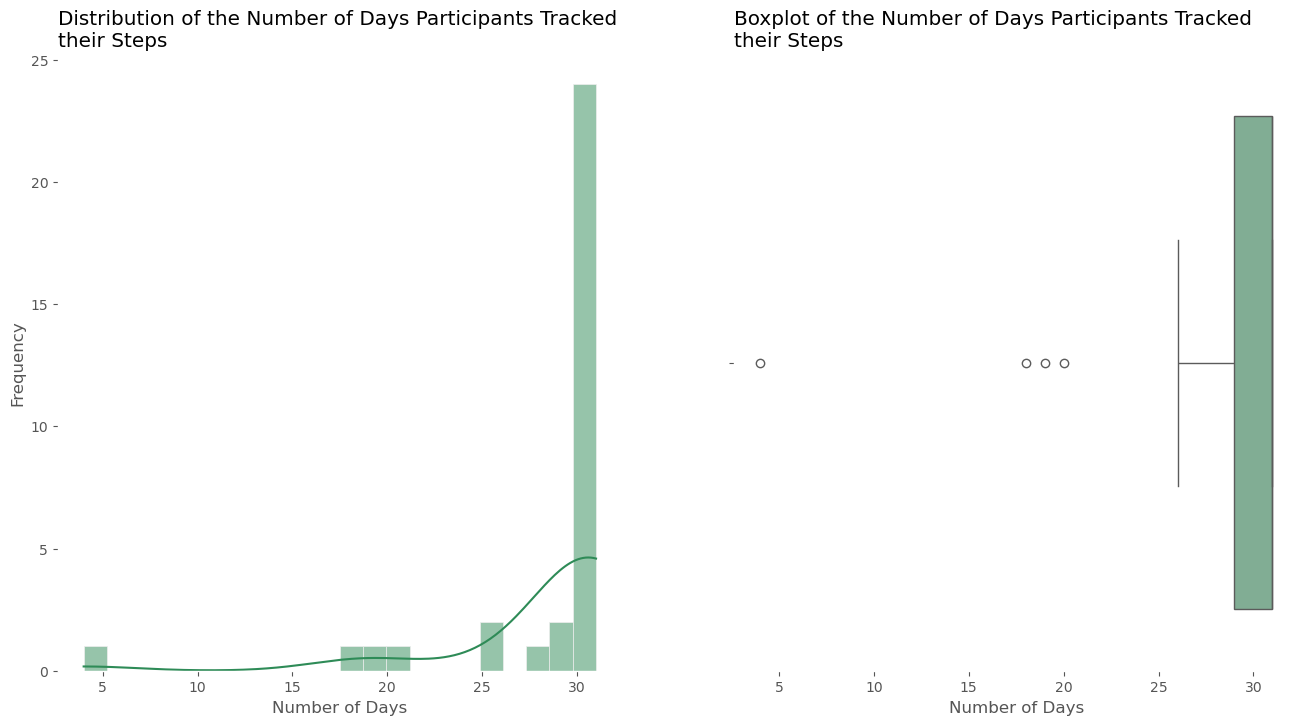

In [397]:
# Creating a histogram and a boxplot
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=days_tracked_steps, x='steps_tracked', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=days_tracked_steps, x='steps_tracked', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Number of Days')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of the Number of Days Participants Tracked \ntheir Steps', loc='left')
ax[1].set_xlabel('Number of Days')
ax[1].set_title('Boxplot of the Number of Days Participants Tracked \ntheir Steps', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

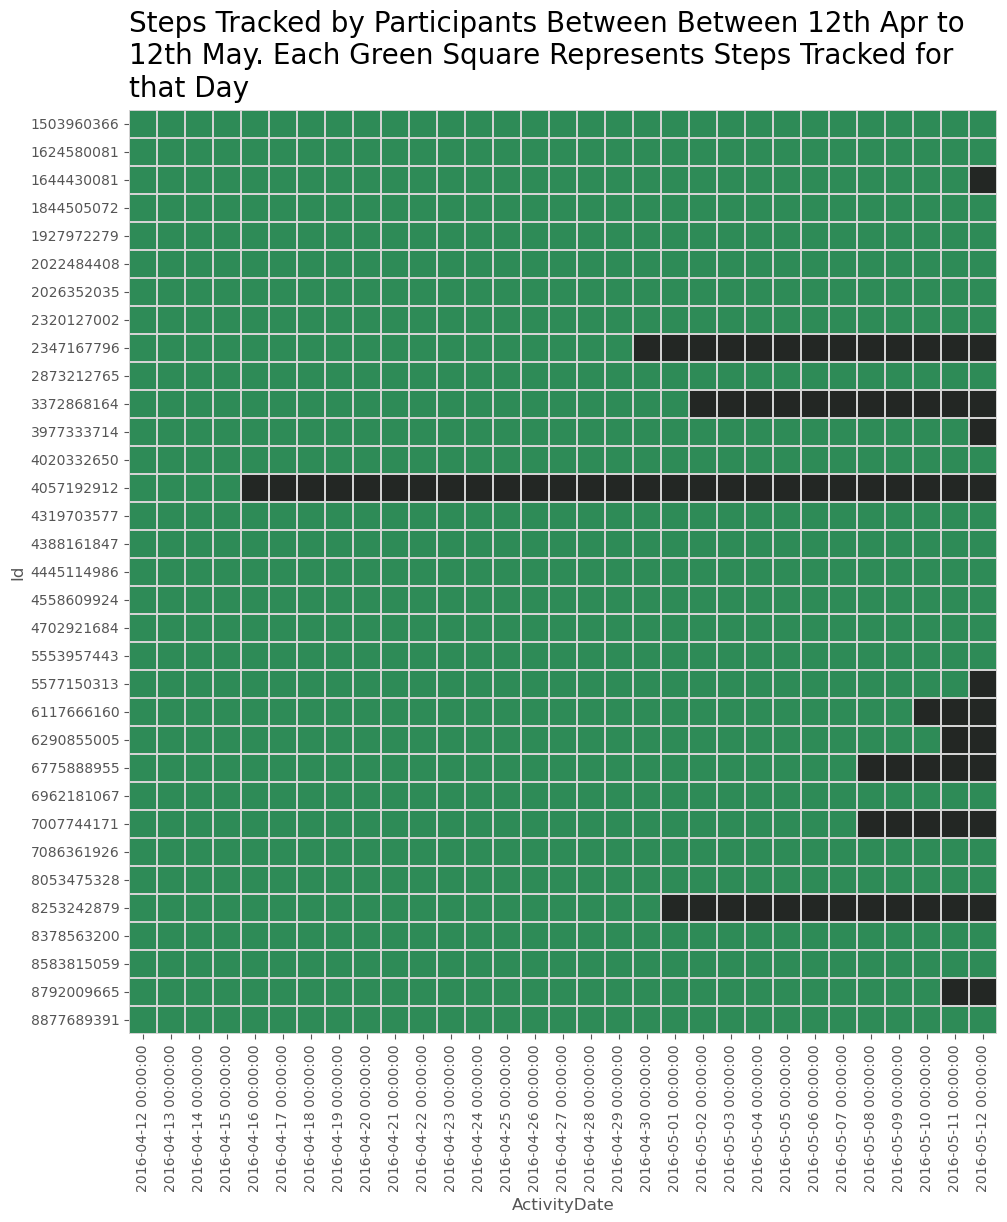

In [692]:
plt.subplots(figsize=(18,12))

# Using a green sequential palette to visualise steps.
seagreen_palette = sns.dark_palette("seagreen")

g = sns.heatmap(steps, square=True, 
                cmap=seagreen_palette, cbar=False,  # type: ignore
                linewidths=0.1, linecolor='lightgrey',
                xticklabels=steps.columns) # type: ignore

g.axes.set_title('Steps Tracked by Participants Between Between 12th Apr to \n12th May. Each Green Square Represents Steps Tracked for \nthat Day',  # type: ignore
                 loc='left', fontsize=20, pad=10)
g.axes.set_facecolor('white') # type: ignore

##### Q2: How many steps do participants take each day?

<ins>Summary of Findings</ins>
- Taking the mean over 31 days, participants took between 916 and 16,000 steps, the median was 7,200 steps.

In [473]:
# Creating a pivot table to understand how many people have their steps tracked
steps_q2 = df.pivot_table(index=['Id'], columns=['ActivityDate'], values=['TotalSteps']) # type: ignore

# The creation of a pivot table comes with unnecessary multi-index columns. In this example it is the 'TotalSteps' column in the zeroth level.
steps_q2.columns = steps_q2.columns.droplevel(0)

# We are now removing the pivot to create a dataframe suitable for plotting the distribution of days where people tracked their steps
steps_num = steps_q2.reset_index().melt(id_vars='Id', var_name='day', value_name='steps_tracked')

# Group the data by participants and counting the number of days their steps are tracked.
num_tracked_steps = steps_num.groupby('Id')[['steps_tracked']].agg('mean')

In [478]:
steps_num.describe()

,Id,steps_tracked
count,1.023000e+03,940.000000
mean,4.857201e+09,7637.910638
std,2.397779e+09,5087.150742
min,1.503960e+09,0.000000
25%,2.347168e+09,3789.750000
50%,4.445115e+09,7405.500000
75%,6.962181e+09,10727.000000
max,8.877689e+09,36019.000000


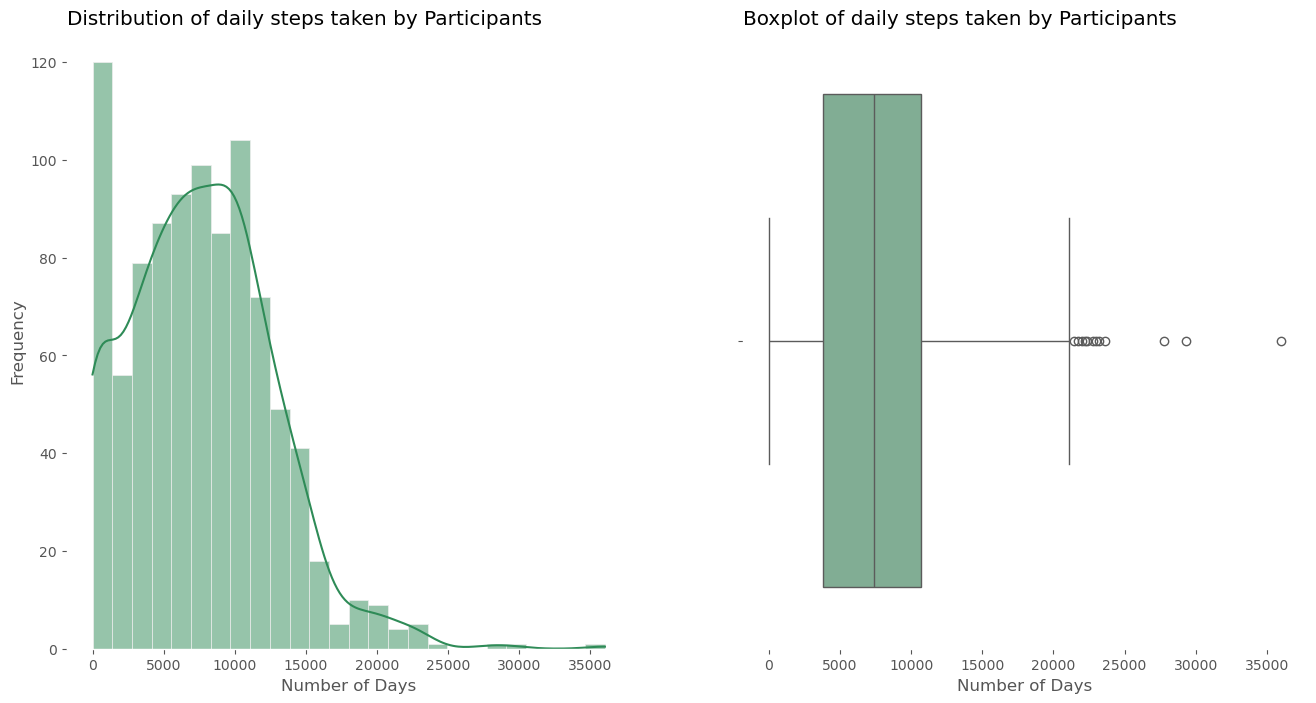

In [480]:
# Plotting participants' daily step count without regard for the identity of the participants. Each count is the number of steps for each day
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=steps_num, x='steps_tracked', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=steps_num, x='steps_tracked', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Number of Days')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of daily steps taken by Participants', loc='left')
ax[1].set_xlabel('Number of Days')
ax[1].set_title('Boxplot of daily steps taken by Participants', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

In [449]:
num_tracked_steps.describe()

,steps_tracked
count,33.000000
mean,7519.272678
std,3576.340125
min,916.129032
25%,5566.870968
50%,7282.966667
75%,9519.666667
max,16040.032258


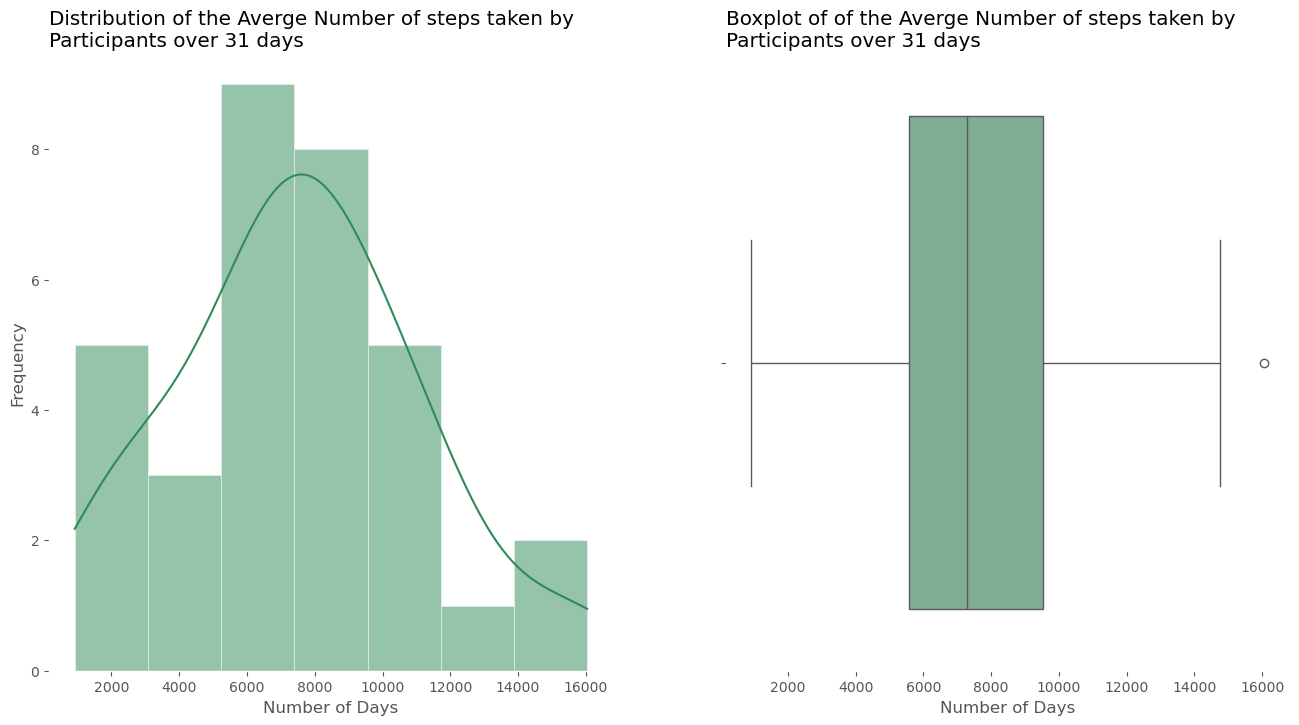

In [481]:
# Here, we took an average of participants daily step count over the 31 days. Each count is the participants mean steps over the 31-day period
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=num_tracked_steps, x='steps_tracked', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=num_tracked_steps, x='steps_tracked', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Number of Days')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of the Averge Number of steps taken by \nParticipants over 31 days', loc='left')
ax[1].set_xlabel('Number of Days')
ax[1].set_title('Boxplot of of the Averge Number of steps taken by \nParticipants over 31 days', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

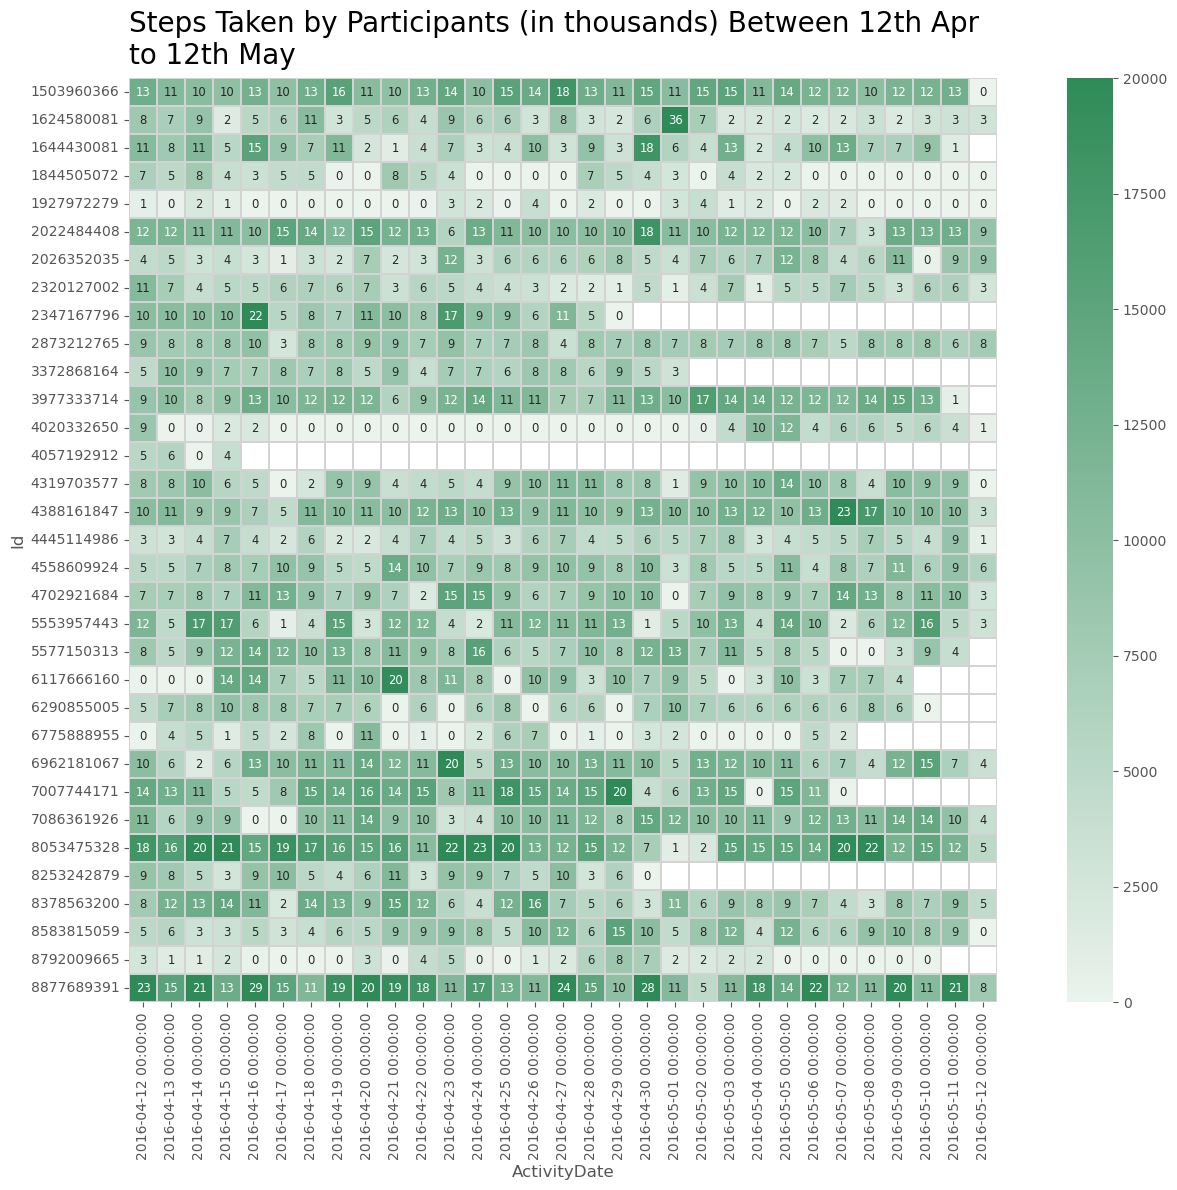

In [562]:
# Here, we plot a heat map showing all participants as rows, and all dates as columns. Each square represents a day and the number represents the steps taken for that day (in thousands)
plt.subplots(figsize=(18,12))

# Using a green sequential palette to visualise steps taken.
seagreen_palette = sns.light_palette("seagreen", as_cmap=True)

# Creating labels for the heatmap
labels = steps_q2.map(lambda x: f'{x/1000:.0f}')

g = sns.heatmap(steps_q2, square=True, 
                cmap=seagreen_palette, cbar=True,  # type: ignore
                vmin=0, vmax=20000,
                linewidths=0.1, linecolor='lightgrey',
                annot=labels, annot_kws={'size':'small', 'alpha':1}, fmt='',
                xticklabels=steps.columns) # type: ignore

g.axes.set_title('Steps Taken by Participants (in thousands) Between 12th Apr \nto 12th May',  # type: ignore
                 loc='left', fontsize=20, pad=10)
g.axes.set_facecolor('white') # type: ignore

####    1.4.2 Sleep

##### Q3: How many days out of 31 days do people track their sleep? Investigating the distribution of sleep records
<ins>Summary of Findings</ins>
- The distribution is bimodal, participants either religiously track their sleep or their do not. There are more people that do not track sleep than those who did. Since the distribution is bimodal, summary statistics might not be very applicable here
- Knowing this allows for the app to make recommendations that encourages people to track their sleep

In [488]:
# creating a dataframe counting the number of days each person logged their sleep in the month
num_of_tracked_sleep_days = df.groupby('Id')[['TotalSleepRecords']].agg('count')
# num_of_tracked_sleep_days

In [492]:
num_of_tracked_sleep_days.describe()

,TotalSleepRecords
count,33.000000
mean,12.424242
std,12.359284
min,0.000000
25%,0.000000
50%,5.000000
75%,26.000000
max,31.000000


Text(0.0, 1.0, 'Distribution of sleep records kept by participants \nover 31 days')

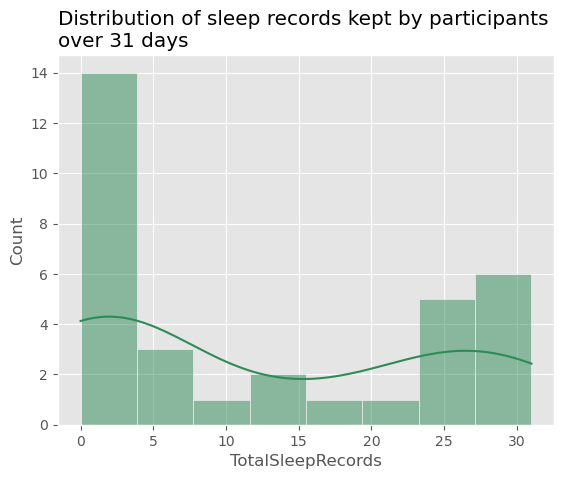

In [517]:
# Creating the histogram of 
g = sns.histplot(data=num_of_tracked_sleep_days, x='TotalSleepRecords', color=sns.light_palette("seagreen")[-1], kde=True, bins=8)
g.axes.set_title('Distribution of sleep records kept by participants \nover 31 days', loc='left') # type: ignore

##### Q4: How many hours did each person sleep per day in the 31-day window?

<ins>Summary of Findings</ins>
- This analysis is conducted for the 24 participants who recorded their sleep in their smart devices.
- The mean hours of sleep is 6.29 hours and the median is 6.59 hours. When median > mean, this meand that the distribution is right-skewed. 

In [530]:
# Creating a pivot table to visualise the number of hours each person sleeps per day in a heatmap. 
sleep_pivot = comb_df.pivot_table(index=['Id'], columns=['ActivityDate'], values=['TotalMinutesAsleep'], dropna=False) # type: ignore

# Creating a pivot table results in uncessary hierarchical columns. Using droplevel to remove unnecessary multi-columns
sleep_pivot.columns = sleep_pivot.columns.droplevel(0).date

# Total minutes asleep is recorded in minutes. Converting it into hours
sleep_pivot = sleep_pivot.divide(60)

sleep_pivot

,2016-04-12,2016-04-13,2016-04-14,2016-04-15,2016-04-16,2016-04-17,2016-04-18,2016-04-19,2016-04-20,2016-04-21,2016-04-22,2016-04-23,2016-04-24,2016-04-25,2016-04-26,2016-04-27,2016-04-28,2016-04-29,2016-04-30,2016-05-01,2016-05-02,2016-05-03,2016-05-04,2016-05-05,2016-05-06,2016-05-07,2016-05-08,2016-05-09,2016-05-10,2016-05-11,2016-05-12
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1503960366,5.450000,6.400000,NaN,6.866667,5.666667,11.666667,NaN,5.066667,6.00,5.416667,NaN,6.016667,7.166667,4.616667,4.083333,NaN,6.100000,5.683333,6.733333,6.150000,4.616667,4.55,NaN,4.116667,5.566667,5.516667,9.900000,5.633333,6.383333,4.750000,NaN
1624580081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1644430081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.983333,2.066667,NaN,13.266667,NaN,NaN,NaN,NaN,NaN,2.283333,NaN,NaN,NaN,NaN
1844505072,NaN,NaN,NaN,10.733333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.033333,9.833333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1927972279,12.500000,6.633333,NaN,7.916667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.933333,NaN,2.766667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8253242879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8378563200,5.633333,7.450000,7.066667,8.550000,10.183333,8.750000,6.633333,6.450000,6.35,6.600000,7.350000,9.416667,7.633333,6.466667,9.166667,8.85,8.433333,8.783333,7.800000,7.916667,5.850000,6.75,7.350000,6.350000,5.383333,7.650000,9.083333,5.983333,5.700000,6.133333,8.266667
8583815059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [541]:
sleep_long = sleep_pivot.mean(axis=1).to_frame()

sleep_long.columns = ['sleep_hrs']

# Note that I have deliberately imputed 0 for null values
# sleep_long.fillna(0, inplace=True)

sleep_long.describe()

,sleep_hrs
count,24.000000
mean,6.290773
std,2.278844
min,1.016667
25%,5.604688
50%,6.954012
75%,7.488021
max,10.866667


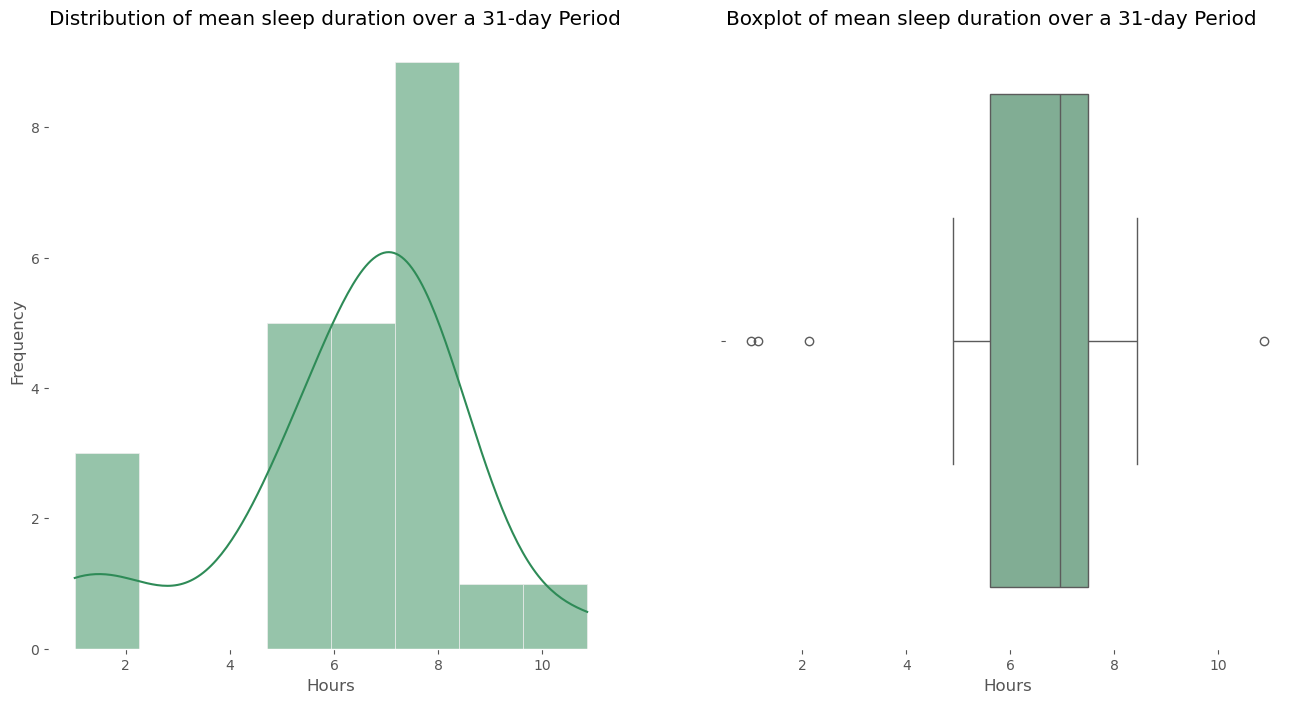

In [540]:
# Plotting participants' daily step count without regard for the identity of the participants. Each count is the number of steps for each day
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=sleep_long, x='sleep_hrs', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=sleep_long, x='sleep_hrs', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Hours')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of mean sleep duration over a 31-day Period', loc='left')
ax[1].set_xlabel('Hours')
ax[1].set_title('Boxplot of mean sleep duration over a 31-day Period', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

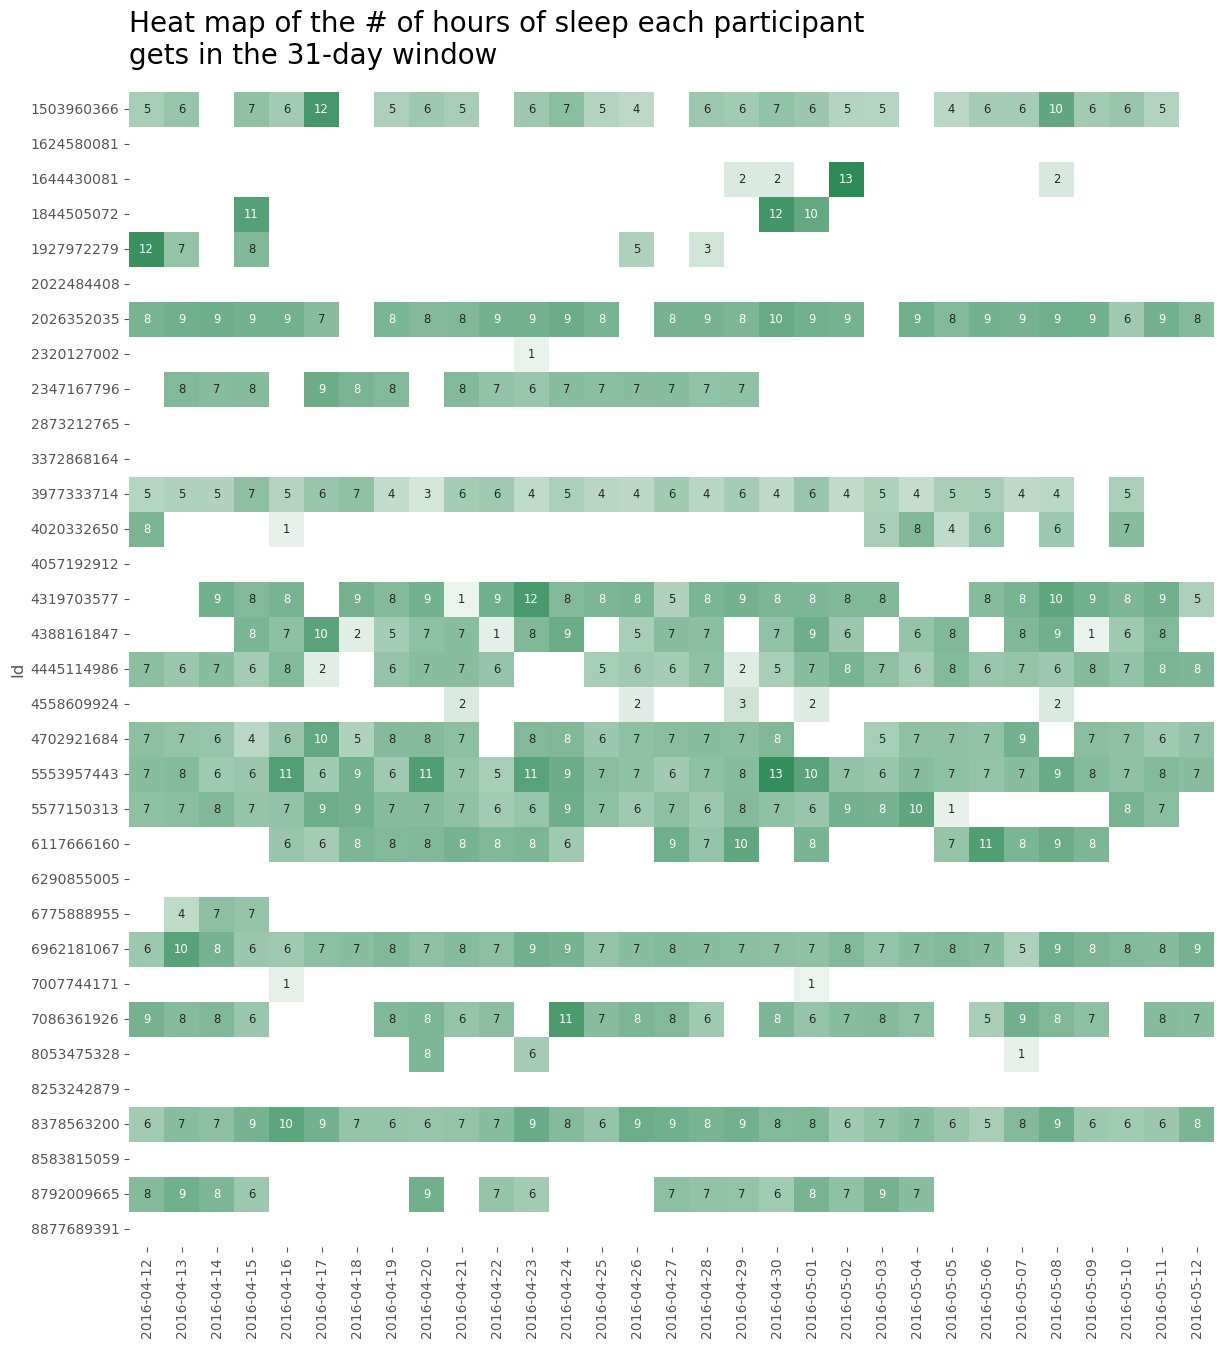

In [499]:
# Setting the size of the visualisation
plt.subplots(figsize=(15,15))

# Using a green sequential palette to visualise sleep. The more intense the colour, the greater the number of hours of sleep
seagreen_palette = sns.light_palette("seagreen", as_cmap=True)

# Creating labels for the heatmap
labels = sleep_pivot.map(lambda x: f'{x:.0f}')

# Creating the visualisation
g = sns.heatmap(sleep_pivot, square=True, cmap=seagreen_palette, 
            annot=labels, annot_kws={'size':'small', 'alpha':1}, 
            fmt='', cbar=False)

g.axes.set_title('Heat map of the # of hours of sleep each participant \ngets in the 31-day window', fontsize=20, loc='left', pad=20) # type: ignore
g.axes.set_facecolor('white')  # type: ignore


##### Q5: Who gets more sleep, those who track their sleep information, or those who dont?

<ins>Summary of Findings</ins>
- It would seem that people who tracked their sleep has a higher average sleep duration. I.e. People who get more sleep tracked their sleep cycles more than those who had gotten less sleep
- We should be wary about making a casual link between tracking sleep and the number of hours of sleep. We <ins>__cannot__</ins> infer that tracking sleep results in more sleep, or vice versa.


In [509]:
# Finding the mean sleep duration for each participant
mean_sleep = sleep_pivot.mean(axis=1)

# If the participant has at least 15 sleep records, s/he is labelled as a tracker, otherwise s/he is labelled as a non-tracker
tracker_label = num_of_tracked_sleep_days['TotalSleepRecords'].apply(lambda x: 'tracker' if x > 15 else 'non-tracker')

# combine the two series together
mean_sleep_with_tracker_label = mean_sleep.to_frame().merge(tracker_label, how='inner', left_index=True, right_index=True)

# renaming the columns
mean_sleep_with_tracker_label.columns = ['mean_sleep_hrs', 'label']

mean_sleep_with_tracker_label

,mean_sleep_hrs,label
Id,,
1503960366,6.004667,tracker
1624580081,NaN,non-tracker
1644430081,4.900000,non-tracker
1844505072,10.866667,non-tracker
1927972279,6.950000,non-tracker
...,...,...
8253242879,NaN,non-tracker
8378563200,7.418817,tracker
8583815059,NaN,non-tracker


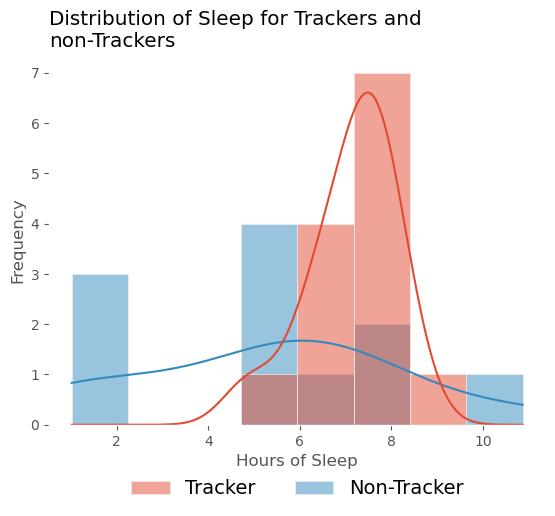

In [510]:
g = sns.histplot(data=mean_sleep_with_tracker_label, x='mean_sleep_hrs', hue='label', kde=True)

g.axes.set_facecolor('white') # type: ignore
g.axes.set_title('Distribution of Sleep for Trackers and \nnon-Trackers', loc='left') # type: ignore
g.axes.set_xlabel('Hours of Sleep') # type: ignore
g.axes.set_ylabel('Frequency') # type: ignore

# Recreating the legend. The main problem is that ax1.get_legend_handles_labels() returns empty lists.
legend = g.axes.get_legend() # type: ignore
handles = legend.legend_handles

# You have to remove the existing legend and recreate the legend
legend.remove()

# Re-creating the legend
g.axes.legend(handles, ['Tracker', 'Non-Tracker'], title='', bbox_to_anchor=(0.5, -0.1), loc='upper center', frameon = False, ncol=2, fontsize=14) # type: ignore

In [512]:
mean_sleep_tracker = mean_sleep_with_tracker_label.query('label == "tracker"')['mean_sleep_hrs'].mean()
mean_sleep_non_tracker = mean_sleep_with_tracker_label.query('label == "non-tracker"')['mean_sleep_hrs'].mean()
print(mean_sleep_tracker, mean_sleep_non_tracker)

7.128339643182551 5.300921717171717


Remarks and Findings:
- The criteria for differentiating sleep trackers and non-sleep trackers is arbitrary. 15 was chosen as it was the halfway point between 0 and 31.
- Based on the histogram and mean sleep hours, it would seem that people who tracked their sleep has a higher average sleep duration

##### Q6: How long do participants sleep?
- Here we plot a histogram of all daily sleep duration. This allows us to compute the mean sleep duration for every one for every day

<ins>Summary of Findings</ins>
- The mean sleep duration is 7.0 hours, median is 7.2 hours, making this a right-skewed graph
- People generally sleep between 6 - 8 hours

In [550]:
# Converting the pivot table, which is a wide data format, into a long data format. 
sleep_long = sleep_pivot.reset_index().melt(id_vars=['Id'], var_name='day', value_name='sleep_hours')
# sleep_long

In [551]:
# Obtaining the summary statstic for sleep duration
sleep_long['sleep_hours'].describe()

count    410.000000
mean       6.986220
std        1.977265
min        0.966667
25%        6.016667
50%        7.208333
75%        8.166667
max       13.266667
Name: sleep_hours, dtype: float64

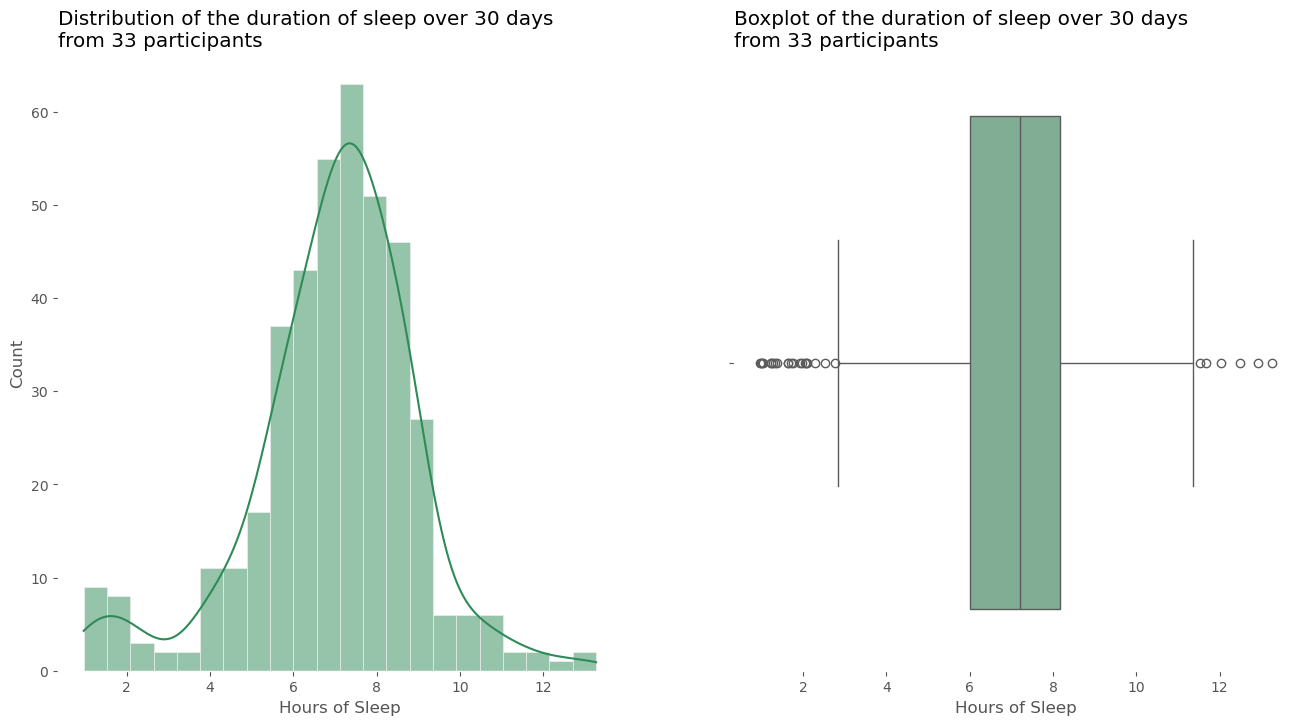

In [549]:
# Drawing the figure
fig, ax = plt.subplots(1, 2, figsize=(16,8))

sns.histplot(data=sleep_long, x='sleep_hours', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=sleep_long, x='sleep_hours', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Hours of Sleep')
ax[0].set_ylabel('Count')
ax[0].set_title('Distribution of the duration of sleep over 30 days \nfrom 33 participants', loc='left')
ax[1].set_xlabel('Hours of Sleep')
ax[1].set_title('Boxplot of the duration of sleep over 30 days \nfrom 33 participants', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

Remarks and Findings
- Sleep data indicates that 50% of sleep have duration between 6-8 hours

##### Q7: Investigating the Time Taken to Fall Asleep
- This investigates the time taken to fall asleep. The average person takes between [15 - 20 minutes][sleep_foundation] to fall asleep. Anything longer or shorter might suggest underlying issues that require medical intervention
- Tracking the time taken to fall asleep is therefore important, and the bellabeat app can suggest strategies for people to cope with longer-than-usual sleep transition times, e.g. sleep hygiene, regular sleep schdules etc.

<ins>Summary of Findings</ins>
- the mean time taken to fall asleep is 39 minutes, and the median is 25 minutes. this is an extremely right skewed graph.
- There are many outliers, some taking more than 200 minutes to fall asleep. Further investigation is needed to check if this is indeed an legitimate result, an error in recording.

[sleep_foundation]: https://www.sleepfoundation.org/sleep-faqs/how-long-should-it-take-to-fall-asleep



In [552]:
df['transition_into_sleep'] = df.loc[:, 'TotalTimeInBed'].subtract(df.loc[:, 'TotalMinutesAsleep'])

In [555]:
df['transition_into_sleep'].describe()

count    410.000000
mean      39.309756
std       46.710932
min        0.000000
25%       17.000000
50%       25.500000
75%       40.000000
max      371.000000
Name: transition_into_sleep, dtype: float64

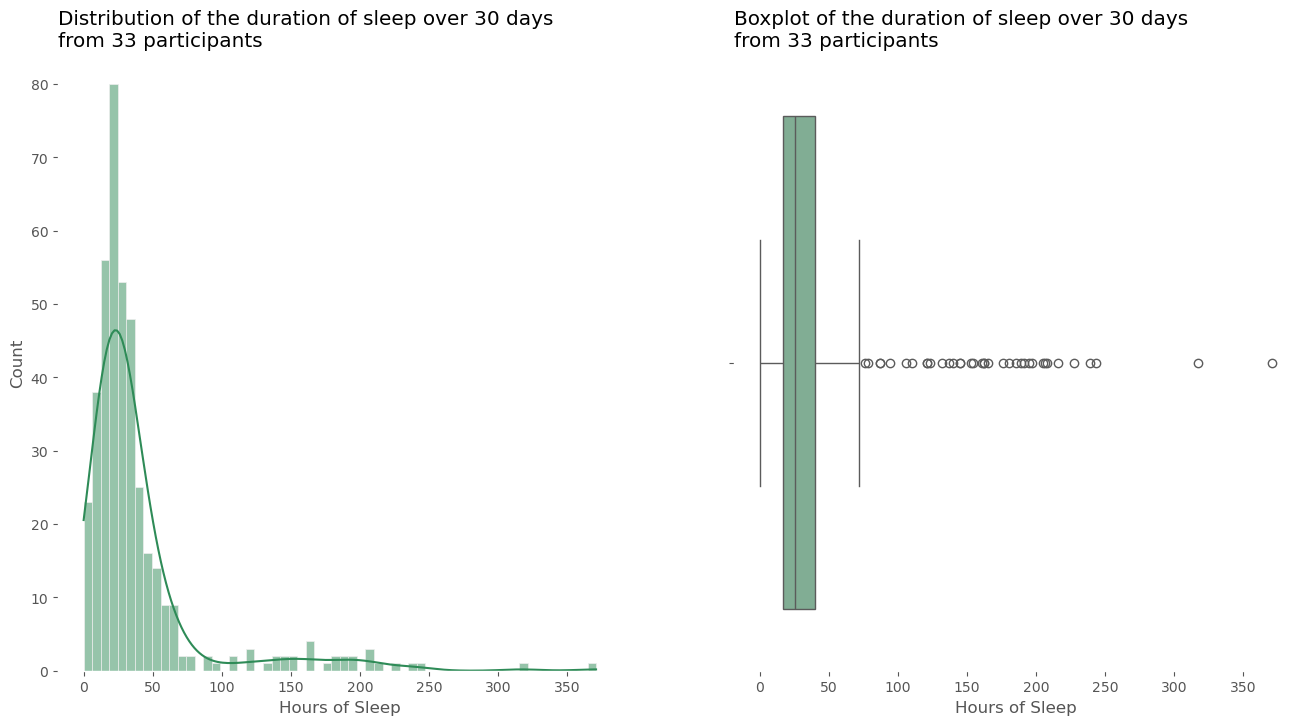

In [694]:
# Drawing the figure
fig, ax = plt.subplots(1, 2, figsize=(16,8))

sns.histplot(data=df, x='transition_into_sleep', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=df, x='transition_into_sleep', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Hours of Sleep')
ax[0].set_ylabel('Count')
ax[0].set_title('Distribution of the duration of sleep over 30 days \nfrom 33 participants', loc='left')
ax[1].set_xlabel('Hours of Sleep')
ax[1].set_title('Boxplot of the duration of sleep over 30 days \nfrom 33 participants', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

#### 1.4.3 Distance

##### Q8: How many people use their smart devices to track distance walked?
- __Caution__: Some distance values are recorded with 2 decimal places while others have 5-6 trailing decimals places. Unless there is a functionality within the wearable that allows participants to manually enter the data, we will need to suspect data credibility issues in this column.
- Everyone has at least one day of distance data in the dataset. This is not surprising because this is automatically tracked when you put on your smart device. The mean number of days tracked is 28 days while the median is 31 days, making this a left-skewed graph.

In [566]:
# pivoting the dataset on Id, Date, and Distance
distance_pivot = df.pivot_table(index=['Id'], columns=['ActivityDate'], values=['TotalDistance']) # type: ignore
# distance_pivot

TotalDistance                                              \
ActivityDate    2016-04-12 2016-04-13 2016-04-14 2016-04-15 2016-04-16   
Id                                                                       
1503960366            8.50       6.97       6.74       6.28   8.160000   
1624580081            5.31       4.55       5.92       0.98   3.490000   
1644430081            7.77       5.82       8.02       3.83  11.120000   
1844505072            4.43       3.26       5.25       2.54   2.260000   
1927972279            0.47       0.25       1.50       0.68   0.000000   
...                    ...        ...        ...        ...        ...   
8253242879            7.16       6.10       3.46       1.77   6.140000   
8378563200            6.05       9.82      10.56      11.47   8.890000   
8583815059            3.91       4.35       2.45       2.68   4.150000   
8792009665            1.64       0.84       0.78       1.59   0.160000   
8877689391           20.40       9.58      18.98       7.17  25.290001   

                                                                     \
ActivityDate 2016-04-17 2016-04-18 2016-04-19 2016-04-20 2016-04-21   
Id                                                                    
1503960366         6.48       8.59       9.88   6.680000   6.340000   
1624580081         4.06       7.41       1.90   3.230000   4.130000   
1644430081         6.37       5.19       8.18   1.770000   0.890000   
1844505072         2.99       3.04       0.13   0.010000   5.320000   
1927972279         0.00       0.17       0.00   0.000000   0.000000   
...                 ...        ...        ...        ...        ...   
8253242879         7.91       3.48       2.78   4.270000   8.560000   
8378563200         1.69      10.81      10.36   7.440000  12.010000   
8583815059         2.35       3.01       4.44   4.110000   6.660000   
8792009665         0.00       0.00       0.00   2.010000   0.090000   
8877689391         8.87       8.67      17.40  18.110001  17.620001   

                                                                     \
ActivityDate 2016-04-22 2016-04-23 2016-04-24 2016-04-25 2016-04-26   
Id                                                                    
1503960366     8.130000       9.04       6.41       9.80       8.79   
1624580081     2.620000       5.55       3.95       4.22       1.84   
1644430081     2.670000       4.83       2.41       2.60       7.21   
1844505072     3.550000       2.36       0.00       0.00       0.00   
1927972279     0.100000       2.04       1.45       0.11       2.60   
...                 ...        ...        ...        ...        ...   
8253242879     1.870000       6.26       7.13       4.51       3.04   
8378563200     9.670000       4.53       2.94       9.84      12.85   
8583815059     6.780000       7.35       6.46       3.51       8.19   
8792009665     2.600000       3.36       0.26       0.00       0.85   
8877689391    16.309999       7.43      15.74       8.74       8.43   

                                                                     \
ActivityDate 2016-04-27 2016-04-28 2016-04-29 2016-04-30 2016-05-01   
Id                                                                    
1503960366        12.21       8.53       7.15   9.250000   6.810000   
1624580081         5.44       1.79       1.55   4.300000  28.030001   
1644430081         2.20       6.84       2.31  13.240000   4.460000   
1844505072         0.00       4.57       3.25   2.670000   1.700000   
1927972279         0.00       1.16       0.00   0.000000   1.870000   
...                 ...        ...        ...        ...        ...   
8253242879         8.18       1.80       4.26   0.000000        NaN   
8378563200         5.84       4.30       4.90   2.340000   9.060000   
8583815059         9.73       4.82      11.83   7.870000   3.520000   
8792009665         1.13       3.94       5.35   4.590000   1.040000   
8877689391        20.65      11.30       7.39  26.719999   8.32

In [592]:
# Creating an array suitable for plotting distributions
distance_forhist = distance_pivot.notna().sum(axis=1).to_frame()
distance_forhist.rename(columns={0: 'days'}, inplace=True)
# distance_forhist

In [593]:
distance_forhist.describe()

,days
count,33.000000
mean,28.484848
std,5.657524
min,4.000000
25%,29.000000
50%,31.000000
75%,31.000000
max,31.000000


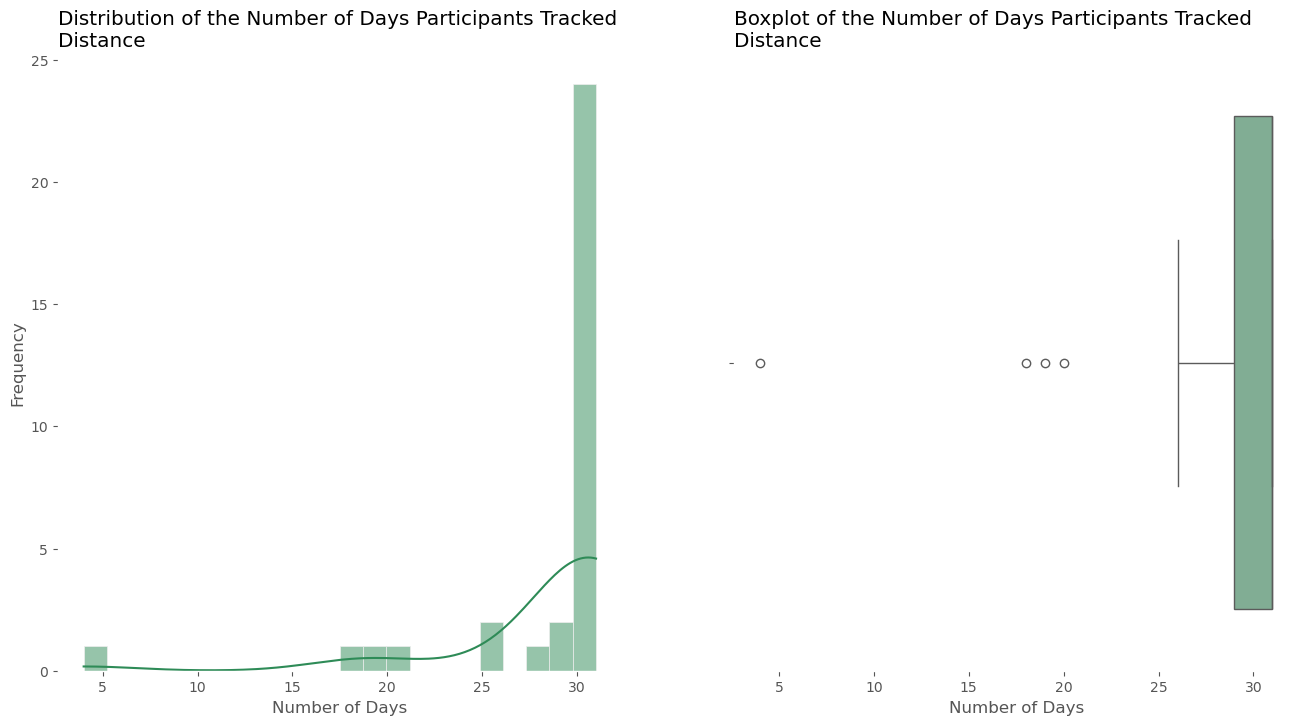

In [594]:
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=distance_forhist, x='days', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=distance_forhist, x='days', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Number of Days')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of the Number of Days Participants Tracked \nDistance', loc='left')
ax[1].set_xlabel('Number of Days')
ax[1].set_title('Boxplot of the Number of Days Participants Tracked \nDistance', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

In [612]:
distance_tracked_bin = distance_pivot.notna()
distance_tracked_bin

TotalDistance                                              \
ActivityDate    2016-04-12 2016-04-13 2016-04-14 2016-04-15 2016-04-16   
Id                                                                       
1503960366            True       True       True       True       True   
1624580081            True       True       True       True       True   
1644430081            True       True       True       True       True   
1844505072            True       True       True       True       True   
1927972279            True       True       True       True       True   
...                    ...        ...        ...        ...        ...   
8253242879            True       True       True       True       True   
8378563200            True       True       True       True       True   
8583815059            True       True       True       True       True   
8792009665            True       True       True       True       True   
8877689391            True       True       True       True       True   

                                                                     \
ActivityDate 2016-04-17 2016-04-18 2016-04-19 2016-04-20 2016-04-21   
Id                                                                    
1503960366         True       True       True       True       True   
1624580081         True       True       True       True       True   
1644430081         True       True       True       True       True   
1844505072         True       True       True       True       True   
1927972279         True       True       True       True       True   
...                 ...        ...        ...        ...        ...   
8253242879         True       True       True       True       True   
8378563200         True       True       True       True       True   
8583815059         True       True       True       True       True   
8792009665         True       True       True       True       True   
8877689391         True       True       True       True       True   

                                                                     \
ActivityDate 2016-04-22 2016-04-23 2016-04-24 2016-04-25 2016-04-26   
Id                                                                    
1503960366         True       True       True       True       True   
1624580081         True       True       True       True       True   
1644430081         True       True       True       True       True   
1844505072         True       True       True       True       True   
1927972279         True       True       True       True       True   
...                 ...        ...        ...        ...        ...   
8253242879         True       True       True       True       True   
8378563200         True       True       True       True       True   
8583815059         True       True       True       True       True   
8792009665         True       True       True       True       True   
8877689391         True       True       True       True       True   

                                                                     \
ActivityDate 2016-04-27 2016-04-28 2016-04-29 2016-04-30 2016-05-01   
Id                                                                    
1503960366         True       True       True       True       True   
1624580081         True       True       True       True       True   
1644430081         True       True       True       True       True   
1844505072         True       True       True       True       True   
1927972279         True       True       True       True       True   
...                 ...        ...        ...        ...        ...   
8253242879         True       True       True       True      False   
8378563200         True       True       True       True       True   
8583815059         True       True       True       True       True   
8792009665         True       True       True       True       True   
8877689391         True       True       True       True       

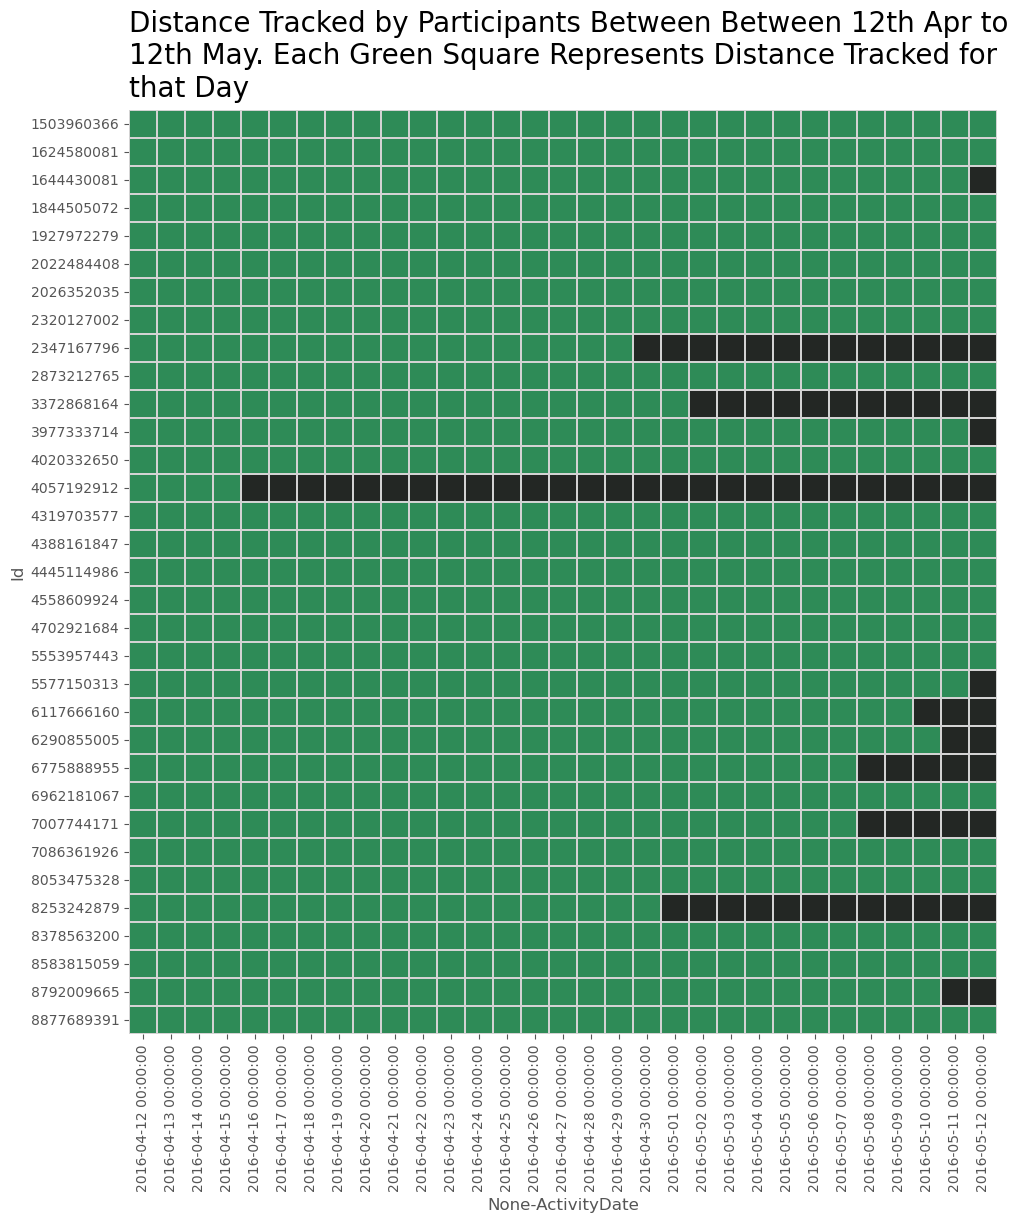

In [614]:
plt.subplots(figsize=(18,12))

# Using a green sequential palette to visualise sleep. The intense green i
seagreen_palette = sns.dark_palette("seagreen")

g = sns.heatmap(distance_tracked_bin, square=True, 
                cmap=seagreen_palette, cbar=False,  # type: ignore
                linewidths=0.1, linecolor='lightgrey',
                xticklabels=steps.columns) # type: ignore

g.axes.set_title('Distance Tracked by Participants Between Between 12th Apr to \n12th May. Each Green Square Represents Distance Tracked for \nthat Day',  # type: ignore
                 loc='left', fontsize=20, pad=10)
g.axes.set_facecolor('white') # type: ignore

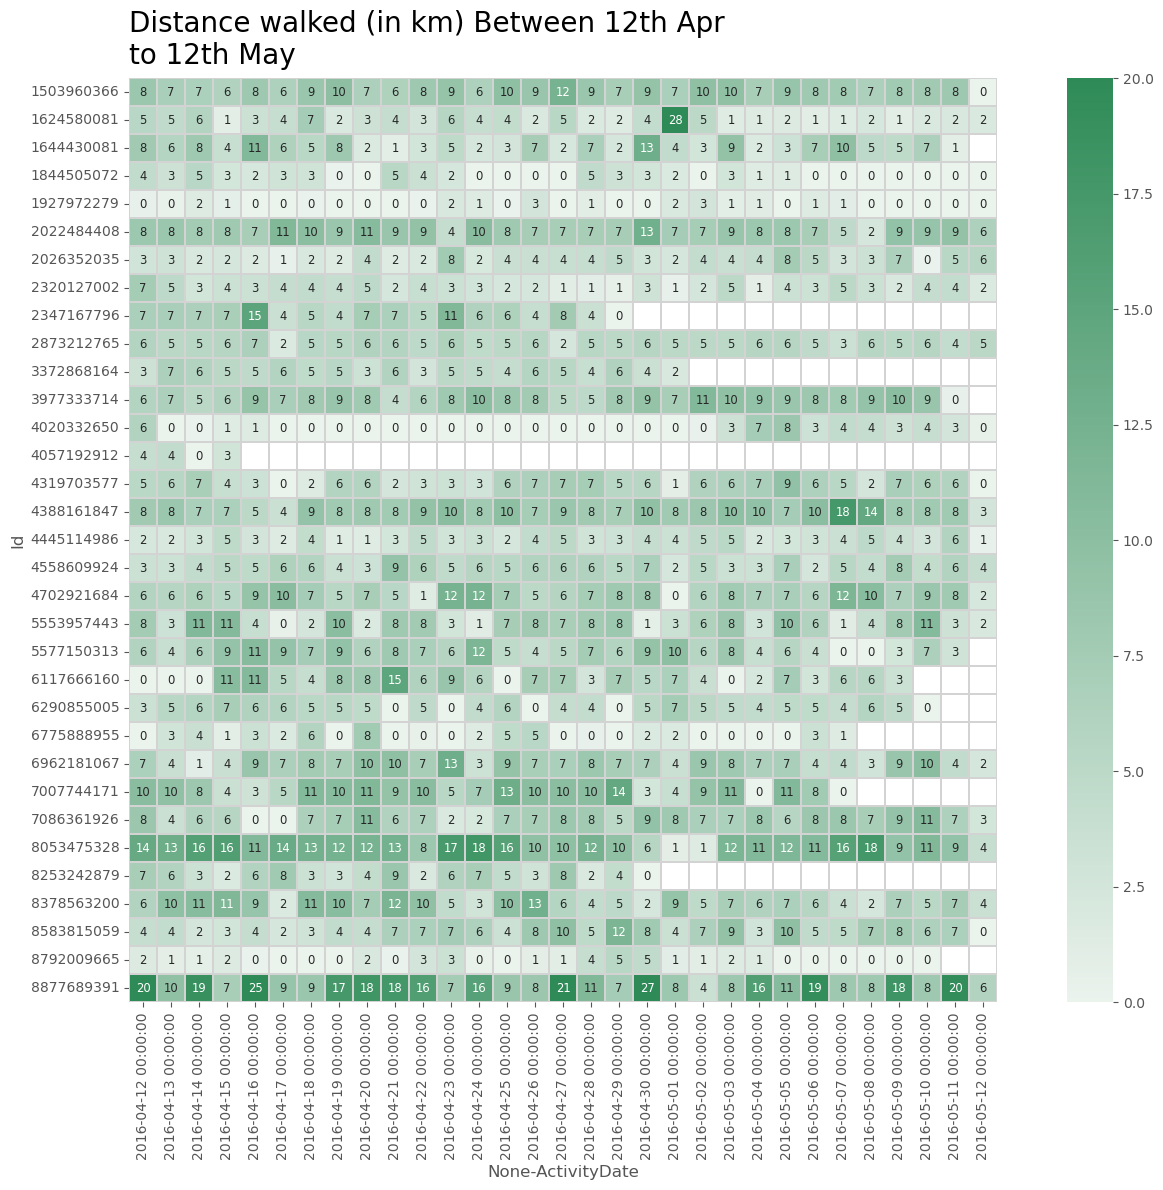

In [565]:
plt.subplots(figsize=(18,12))

# Using a green sequential palette to visualise sleep. The intense green i
seagreen_palette = sns.light_palette("seagreen", as_cmap=True)

# Creating labels for the heatmap
labels = distance_pivot.map(lambda x: f'{x:.0f}')

g = sns.heatmap(distance_pivot, square=True, 
                cmap=seagreen_palette, cbar=True,  # type: ignore
                vmin=0, vmax=20,
                linewidths=0.1, linecolor='lightgrey',
                annot=labels, annot_kws={'size':'small', 'alpha':1}, fmt='',
                xticklabels=steps.columns) # type: ignore

g.axes.set_title('Distance walked (in km) Between 12th Apr \nto 12th May',  # type: ignore
                 loc='left', fontsize=20, pad=10)
g.axes.set_facecolor('white') # type: ignore

##### Q9: If we take the average of distance travelled for each participant, What is the mean distance walked for the entire dataset?
<ins> Summary of Findings</ins>
- On average, particiapnts travelled 5.4km every day

In [601]:
# Creating an array suitable for plotting distributions
distance_km_forhist = distance_pivot.mean(axis=1).to_frame()
distance_km_forhist.rename(columns={0: 'km'}, inplace=True)
# distance_km_forhist

,km
Id,
1503960366,7.809677
1624580081,3.914839
1644430081,5.295333
1844505072,1.706129
1927972279,0.634516
...,...
8253242879,4.667368
8378563200,6.913548
8583815059,5.615484


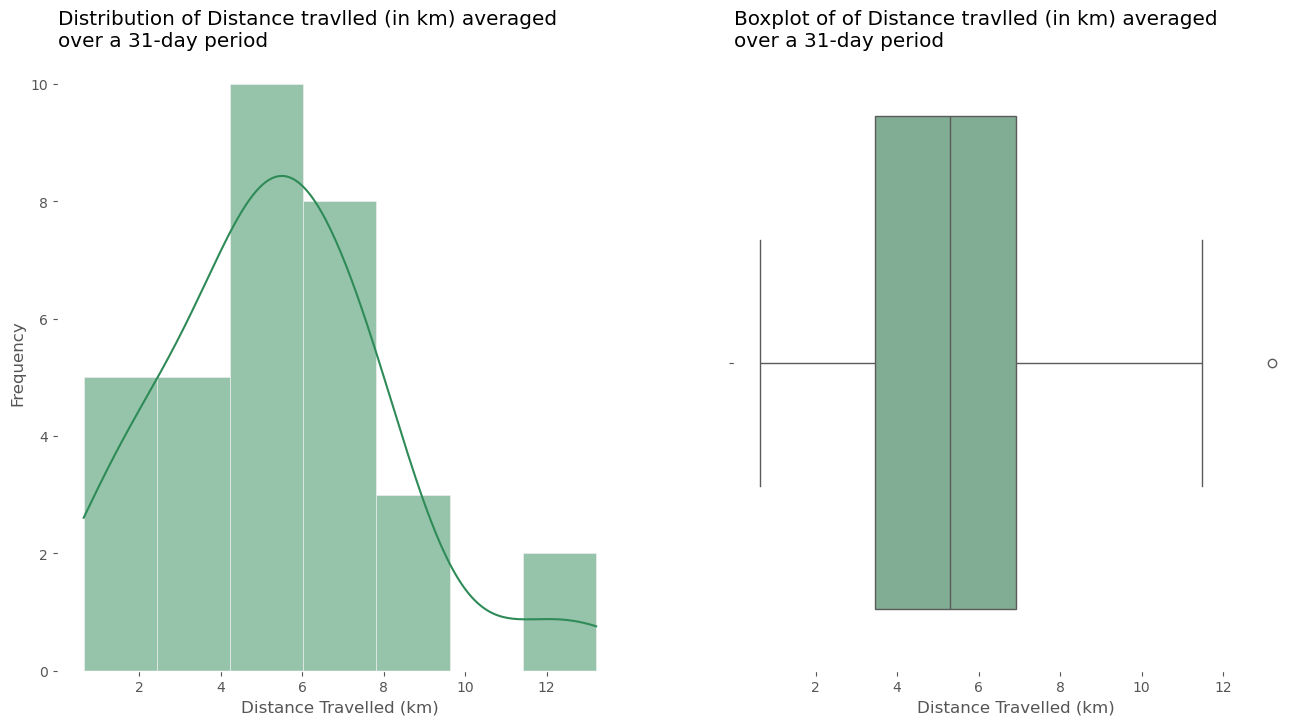

In [609]:
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=distance_km_forhist, x='km', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=distance_km_forhist, x='km', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Distance Travelled (km)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of Distance travlled (in km) averaged \nover a 31-day period', 
                loc='left')
ax[1].set_xlabel('Distance Travelled (km)')
ax[1].set_title('Boxplot of of Distance travlled (in km) averaged \nover a 31-day period', 
                loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

##### Q10: Understanding the Distances columns
- Here, I am trying to understand the relationship between `'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance'`, `TotalDistance`, and `TrackerDistance`.
- The difference between `TotalDistance` and `'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance'` is almost zero for most, but there are large occasional discrepancies in distances of up to 9km in some instances.
- Wihtout further information to inform us about how these distances are recorded and calculated, it is hard to derive further information with these columns.
- We should retain Q2's conclusion that distance data can be found in many of the participants' tracking data

<Axes: >

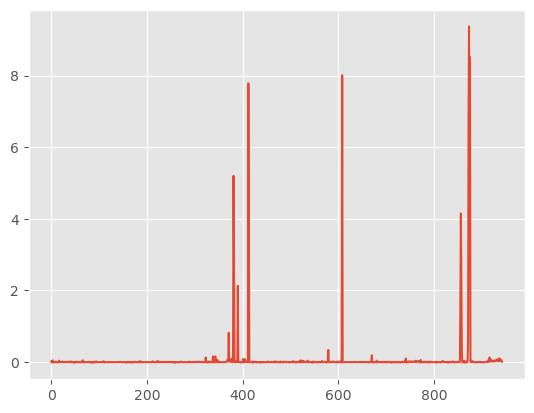

In [688]:
(df['TotalDistance'] - df.loc[:, ['VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance']].sum(axis=1)).plot()

#### 1.4.4 Logged Activities

##### Q11: How many people logged their activities?
- Note that `LoggedActivitiesDistance` + `TrackerDistance` =/= `Total Distance`. so there is some form of double-counting of distance between `TrackerDistance` and `LoggedActivitiesDistance` that we are not aware of. 
- Here, I will make the assumption that `TrackerDistance` is the distance that the weareable tracks in the background. For `LoggedActivitiesDistance` to be recorded, the wearer has to manually press a button on the wearable to track the distance.
- It is difficult to infer the difference between a value of a 0 and a null in the `LoggedActivitiesDistance` column. I will make a further assumption that for this column, there is no difference between zeroes and nulls and they are treated the same in this part of the anaylsis. 

<ins>Summary of Findings</ins>
- Majority of people do not log in activities. Mean distance logged is 0.96km and the median distance is also 0km
- As we have seen in previous findings, trackers that work in the background are more comprehensive in capturing data compared to those that require manual activation by users. As much as possible, we need to find ways to automate the tracking of distance or exercise instead of relying on manual activation. Alternatively, we can use certain indicators to identify the activity that the user is doing and prompt the user to manually activate the activity, e.g. higher heart rate for ~10mins indicates that the participants might be exercising

In [646]:
# Making a pivot table to investigate how many people log their activities, and on which day peoplelog their activities
logged_activities = df.pivot_table(index=['Id'], columns=['ActivityDate'], values=['LoggedActivitiesDistance']) # type: ignore
logged_activities

LoggedActivitiesDistance                                   \
ActivityDate               2016-04-12 2016-04-13 2016-04-14 2016-04-15   
Id                                                                       
1503960366                   0.000000   0.000000   0.000000        0.0   
1624580081                   0.000000   0.000000   0.000000        0.0   
1644430081                   0.000000   0.000000   0.000000        0.0   
1844505072                   0.000000   0.000000   0.000000        0.0   
1927972279                   0.000000   0.000000   0.000000        0.0   
...                               ...        ...        ...        ...   
8253242879                   0.000000   0.000000   0.000000        0.0   
8378563200                   2.253081   2.092147   2.253081        0.0   
8583815059                   0.000000   0.000000   0.000000        0.0   
8792009665                   0.000000   0.000000   0.000000        0.0   
8877689391                   0.000000   0.000000   0.000000        0.0   

                                                                     \
ActivityDate 2016-04-16 2016-04-17 2016-04-18 2016-04-19 2016-04-20   
Id                                                                    
1503960366          0.0        0.0   0.000000   0.000000   0.000000   
1624580081          0.0        0.0   0.000000   0.000000   0.000000   
1644430081          0.0        0.0   0.000000   0.000000   0.000000   
1844505072          0.0        0.0   0.000000   0.000000   0.000000   
1927972279          0.0        0.0   0.000000   0.000000   0.000000   
...                 ...        ...        ...        ...        ...   
8253242879          0.0        0.0   0.000000   0.000000   0.000000   
8378563200          0.0        0.0   2.092147   2.253081   2.092147   
8583815059          0.0        0.0   0.000000   0.000000   0.000000   
8792009665          0.0        0.0   0.000000   0.000000   0.000000   
8877689391          0.0        0.0   0.000000   0.000000   0.000000   

                                                                     \
ActivityDate 2016-04-21 2016-04-22 2016-04-23 2016-04-24 2016-04-25   
Id                                                                    
1503960366     0.000000   0.000000        0.0        0.0   0.000000   
1624580081     0.000000   0.000000        0.0        0.0   0.000000   
1644430081     0.000000   0.000000        0.0        0.0   0.000000   
1844505072     0.000000   0.000000        0.0        0.0   0.000000   
1927972279     0.000000   0.000000        0.0        0.0   0.000000   
...                 ...        ...        ...        ...        ...   
8253242879     0.000000   0.000000        0.0        0.0   0.000000   
8378563200     2.253081   2.092147        0.0        0.0   2.092147   
8583815059     0.000000   0.000000        0.0        0.0   0.000000   
8792009665     0.000000   0.000000        0.0        0.0   0.000000   
8877689391     0.000000   0.000000        0.0        0.0   0.000000   

                                                                     \
ActivityDate 2016-04-26 2016-04-27 2016-04-28 2016-04-29 2016-04-30   
Id                                                                    
1503960366          0.0        0.0        0.0        0.0        0.0   
1624580081          0.0        0.0        0.0        0.0        0.0   
1644430081          0.0        0.0        0.0        0.0        0.0   
1844505072          0.0        0.0        0.0        0.0        0.0   
1927972279          0.0        0.0        0.0        0.0        0.0   
...                 ...        ...        ...        ...        ...   
8253242879          0.0        0.0        0.0        0.0        0.0   
8378563200          0.0        0.0        0.0        0.0        0.0   
8583815059          0.0        0.0        0.0        0.0        0.0   
8792009665          0.0        0.0        0.0        0.0        0.0   
8877689391          0.0        0.0        0.0        0.0       

In [689]:
logged_act_forhist = logged_activities.replace(0, np.nan)
logged_act_forhist = logged_act_forhist.notna().sum(axis=1).to_frame() # type: ignore
logged_act_forhist.rename(columns={0:'days'}, inplace=True)

# logged_act_forhist

In [656]:
logged_act_forhist.describe()


,days
count,33.000000
mean,0.969697
std,3.441337
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,16.000000


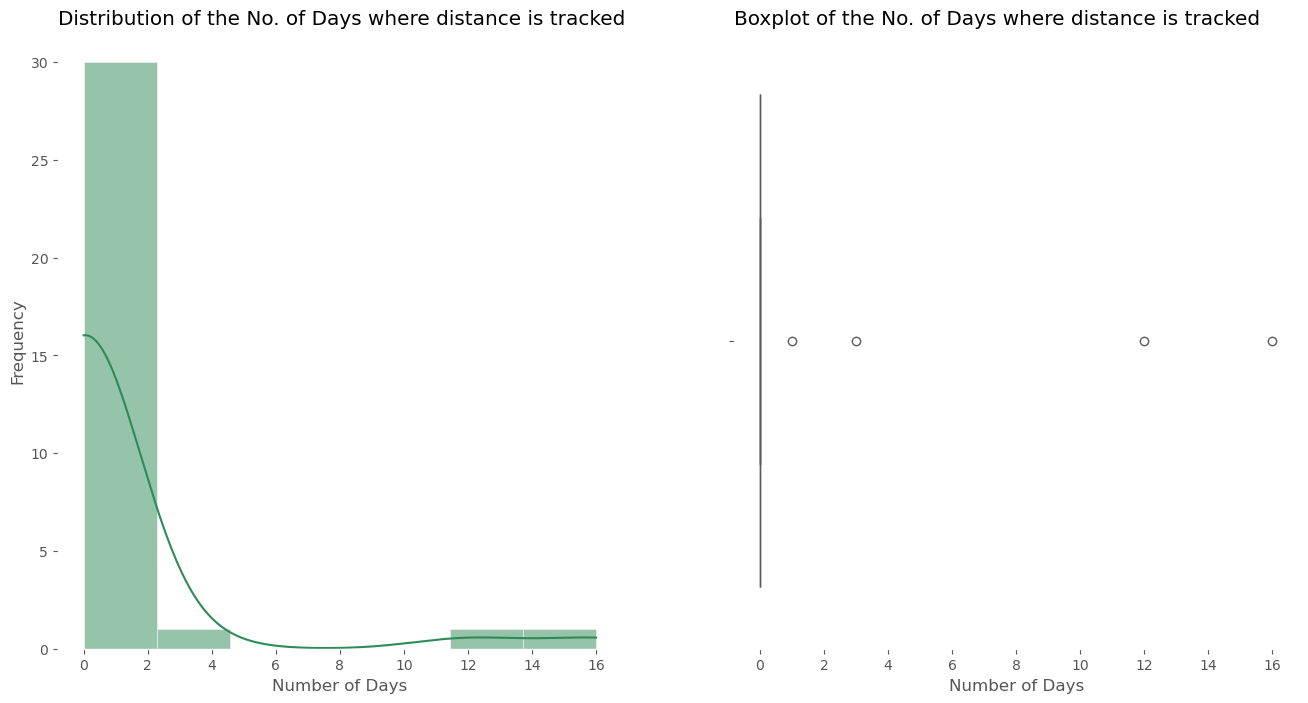

In [657]:
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=logged_act_forhist, x='days', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=logged_act_forhist, x='days', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Number of Days')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of the No. of Days where distance is tracked', loc='left')
ax[1].set_xlabel('Number of Days')
ax[1].set_title('Boxplot of the No. of Days where distance is tracked', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

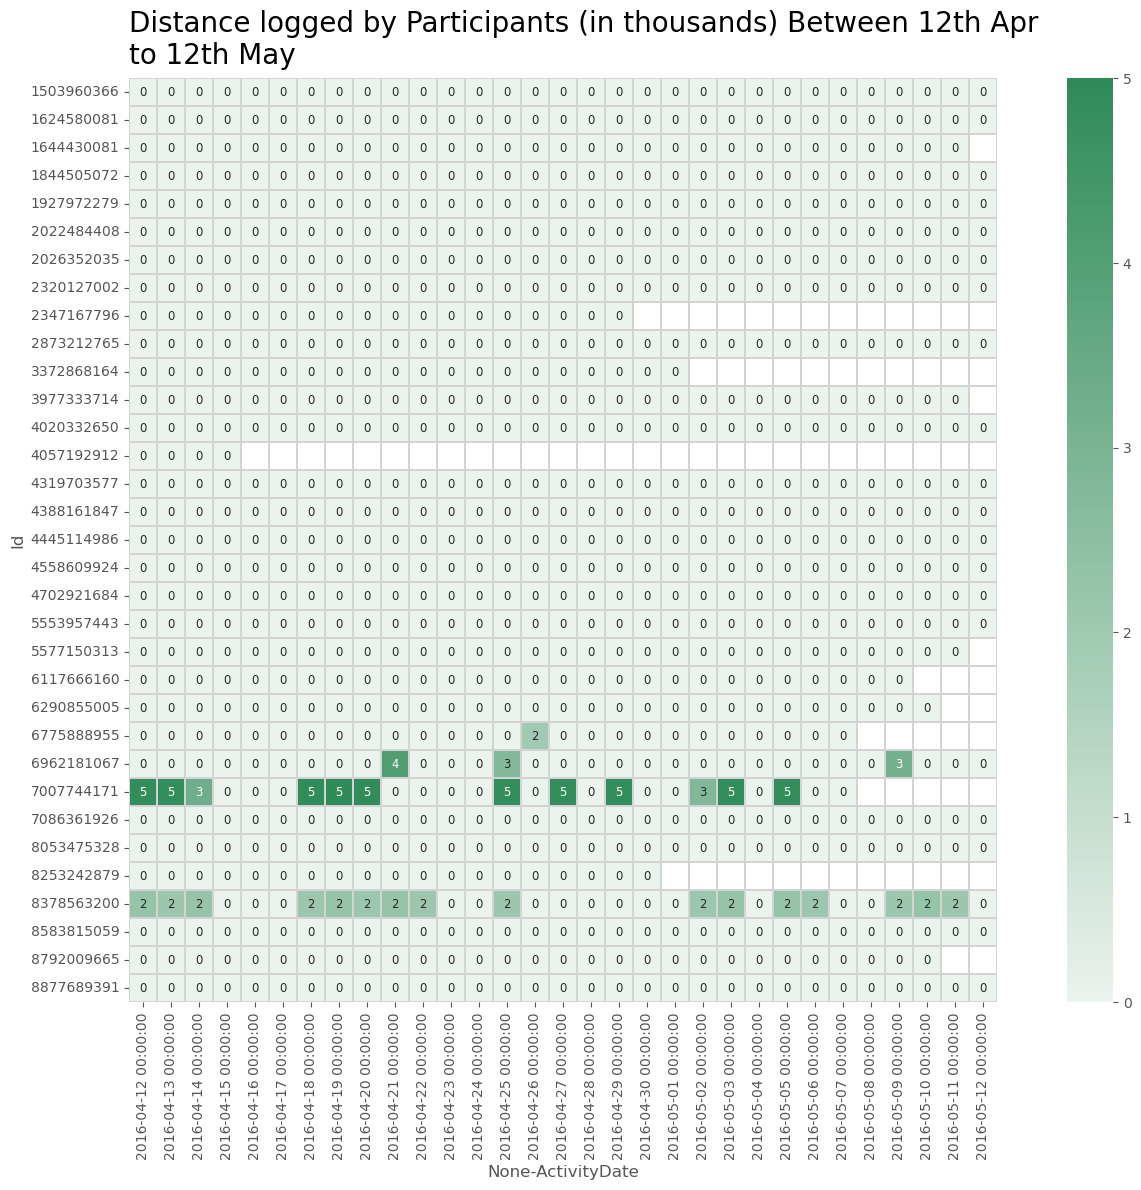

In [658]:
plt.subplots(figsize=(18,12))

# Using a green sequential palette to visualise sleep. The intense green i
seagreen_palette = sns.light_palette("seagreen", as_cmap=True)

# Creating labels for the heatmap
labels = logged_activities.map(lambda x: f'{x:.0f}')

g = sns.heatmap(logged_activities, square=True, 
                cmap=seagreen_palette, cbar=True,  # type: ignore
                vmin=0, vmax=5,
                linewidths=0.1, linecolor='lightgrey',
                annot=labels, annot_kws={'size':'small', 'alpha':1}, fmt='',
                xticklabels=steps.columns) # type: ignore

g.axes.set_title('Distance logged by Participants (in thousands) Between 12th Apr \nto 12th May',  # type: ignore
                 loc='left', fontsize=20, pad=10)
g.axes.set_facecolor('white') # type: ignore

Findings:
- The light-green coloured boxes represent values that are zero, while white-coloured boxes represent values that are null. It is unclear what the differences are. 
- One hypothesis differenting zero and null values might be that the participants who wore the smart devices and did not make any distance logs had their distance recorded as zero, while participants who did not wear the smart at all had their ditsnaces recorded as null values
- Suffice to say the bulk of participants did not log their activities for the associated distances to be captured

#### 1.4.5 Calories

##### Q12: How many people in the dataset track their calories. If they tracked their calories, how many days of the month did they track it for? 
- It is unsure what do calories mean in this situation, does 'calories' here refer to calories consumed or calories expended?
- There is no (simple) way to automate the collection of calories consumption data. I make the assumption that all calorie consumption data has to be manually recorded into a smart device. 
- If everyone in the dataset has used their weareables to track their calorie consumption, then this is incongruent to prior observations that manual data collection records such comprehensive data
- Triangulating from prior observations of the dataset, we can conclude that calories here refer to calorie expenditure and not consumption

<ins>Summary of Findings</ins>
- Everyone has a record of calories (expenditure) in the dataset. Mean records was found to be 28 days and Median 31 days.

In [660]:
# Prepare a pivot table with Id, Date, and calories
calories_pivot = df.pivot_table(index=['Id'], columns=['ActivityDate'], values=['Calories']) # type: ignore
calories_pivot 

Calories                                              \
ActivityDate 2016-04-12 2016-04-13 2016-04-14 2016-04-15 2016-04-16   
Id                                                                    
1503960366       1985.0     1797.0     1776.0     1745.0     1863.0   
1624580081       1432.0     1411.0     1572.0     1344.0     1463.0   
1644430081       3199.0     2902.0     3226.0     2750.0     3493.0   
1844505072       2030.0     1860.0     2130.0     1725.0     1657.0   
1927972279       2220.0     2151.0     2383.0     2221.0     2064.0   
...                 ...        ...        ...        ...        ...   
8253242879       2044.0     1935.0     1705.0     1632.0     1880.0   
8378563200       3635.0     4079.0     4163.0     3666.0     3363.0   
8583815059       2650.0     2654.0     2443.0     2505.0     2693.0   
8792009665       2044.0     1934.0     1963.0     2009.0     1721.0   
8877689391       3921.0     3566.0     3793.0     3934.0     4547.0   

                                                                     \
ActivityDate 2016-04-17 2016-04-18 2016-04-19 2016-04-20 2016-04-21   
Id                                                                    
1503960366       1728.0     1921.0     2035.0     1786.0     1775.0   
1624580081       1554.0     1604.0     1435.0     1446.0     1467.0   
1644430081       3011.0     2806.0     3300.0     2430.0     2140.0   
1844505072       1793.0     1814.0     1366.0     1349.0     2062.0   
1927972279       2063.0     2111.0     2063.0     2063.0     2064.0   
...                 ...        ...        ...        ...        ...   
8253242879       2112.0     1829.0     1763.0     1931.0     2218.0   
8378563200       2572.0     4157.0     4092.0     3787.0     4236.0   
8583815059       2439.0     2536.0     2668.0     2647.0     2883.0   
8792009665       1688.0     1688.0     1688.0     2188.0     1720.0   
8877689391       3545.0     2761.0     3676.0     3679.0     3659.0   

                                                                     \
ActivityDate 2016-04-22 2016-04-23 2016-04-24 2016-04-25 2016-04-26   
Id                                                                    
1503960366       1827.0     1949.0     1788.0     2013.0     1970.0   
1624580081       1470.0     1562.0     1617.0     1492.0     1402.0   
1644430081       2344.0     2677.0     2413.0     2497.0     3123.0   
1844505072       1827.0     1645.0     1347.0     1347.0     1347.0   
1927972279       2093.0     2499.0     2324.0     2100.0     2638.0   
...                 ...        ...        ...        ...        ...   
8253242879       1651.0     2132.0     1976.0     1909.0     1813.0   
8378563200       4044.0     2908.0     2741.0     4005.0     3763.0   
8583815059       2944.0     3012.0     2889.0     2547.0     3093.0   
8792009665       2419.0     2748.0     1799.0     1688.0     1928.0   
8877689391       3427.0     3891.0     3455.0     3802.0     2860.0   

                                                                     \
ActivityDate 2016-04-27 2016-04-28 2016-04-29 2016-04-30 2016-05-01   
Id                                                                    
1503960366       2159.0     1898.0     1837.0     1947.0     1820.0   
1624580081       1670.0     1401.0     1404.0     1655.0     2690.0   
1644430081       2489.0     3108.0     2498.0     3846.0     2696.0   
1844505072       1348.0     1992.0     1856.0     1763.0     1541.0   
1927972279       2063.0     2351.0     2063.0     2064.0     2411.0   
...                 ...        ...        ...        ...        ...   
8253242879       2008.0     1580.0     1854.0        0.0        NaN   
8378563200       3061.0     2884.0     2982.0     2660.0     3369.0   
8583815059       3142.0     2757.0     3513.0     3164.0     2596.0   
8792009665       2067.0     2780.0     3101.0     2896.0     1962.0   
8877689391       3808.0     3060.0     2698.0     4398.0     2786.0   

                                   

In [671]:
# Preparing a dataframe suitable for plotting distributions
calories_long = calories_pivot.notna().sum(axis=1).reset_index()
calories_long.rename(columns={0:'days'}, inplace=True)

In [673]:
calories_long['days'].describe()

count    33.000000
mean     28.484848
std       5.657524
min       4.000000
25%      29.000000
50%      31.000000
75%      31.000000
max      31.000000
Name: days, dtype: float64

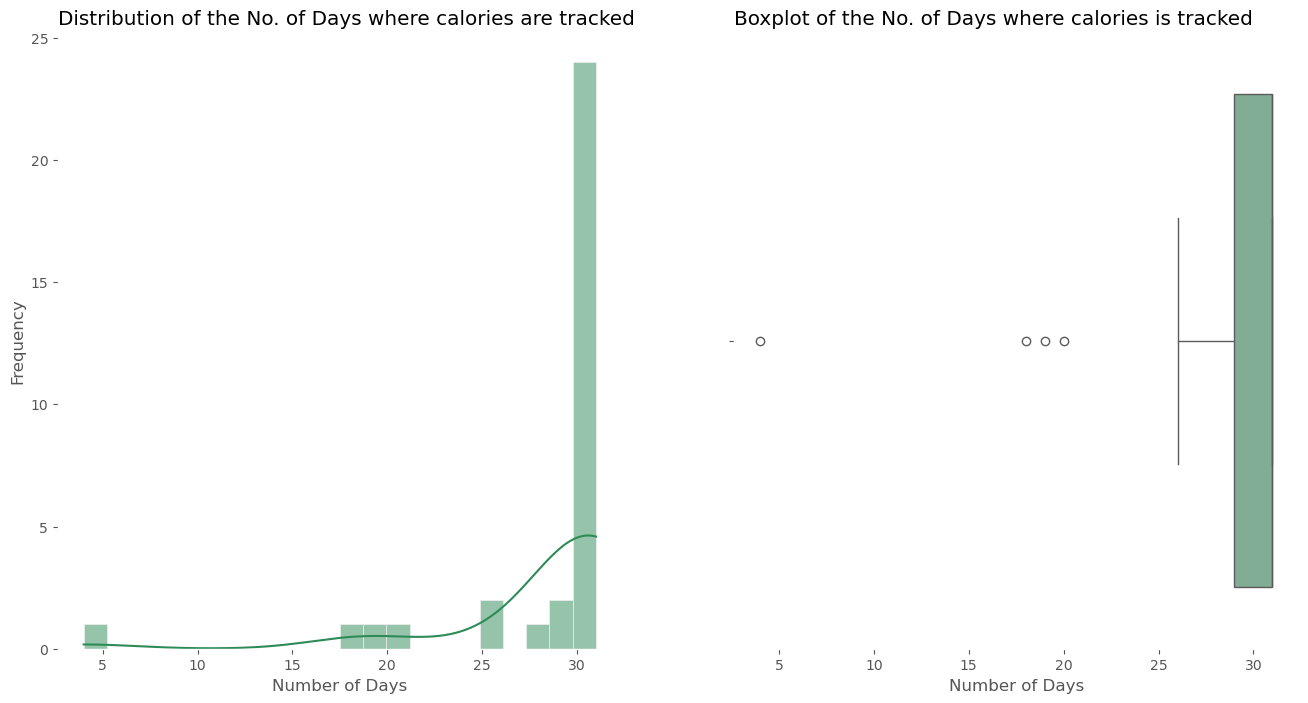

In [669]:
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=calories_long, x='days', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=calories_long, x='days', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Number of Days')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of the No. of Days where calories are tracked', loc='left')
ax[1].set_xlabel('Number of Days')
ax[1].set_title('Boxplot of the No. of Days where calories is tracked', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

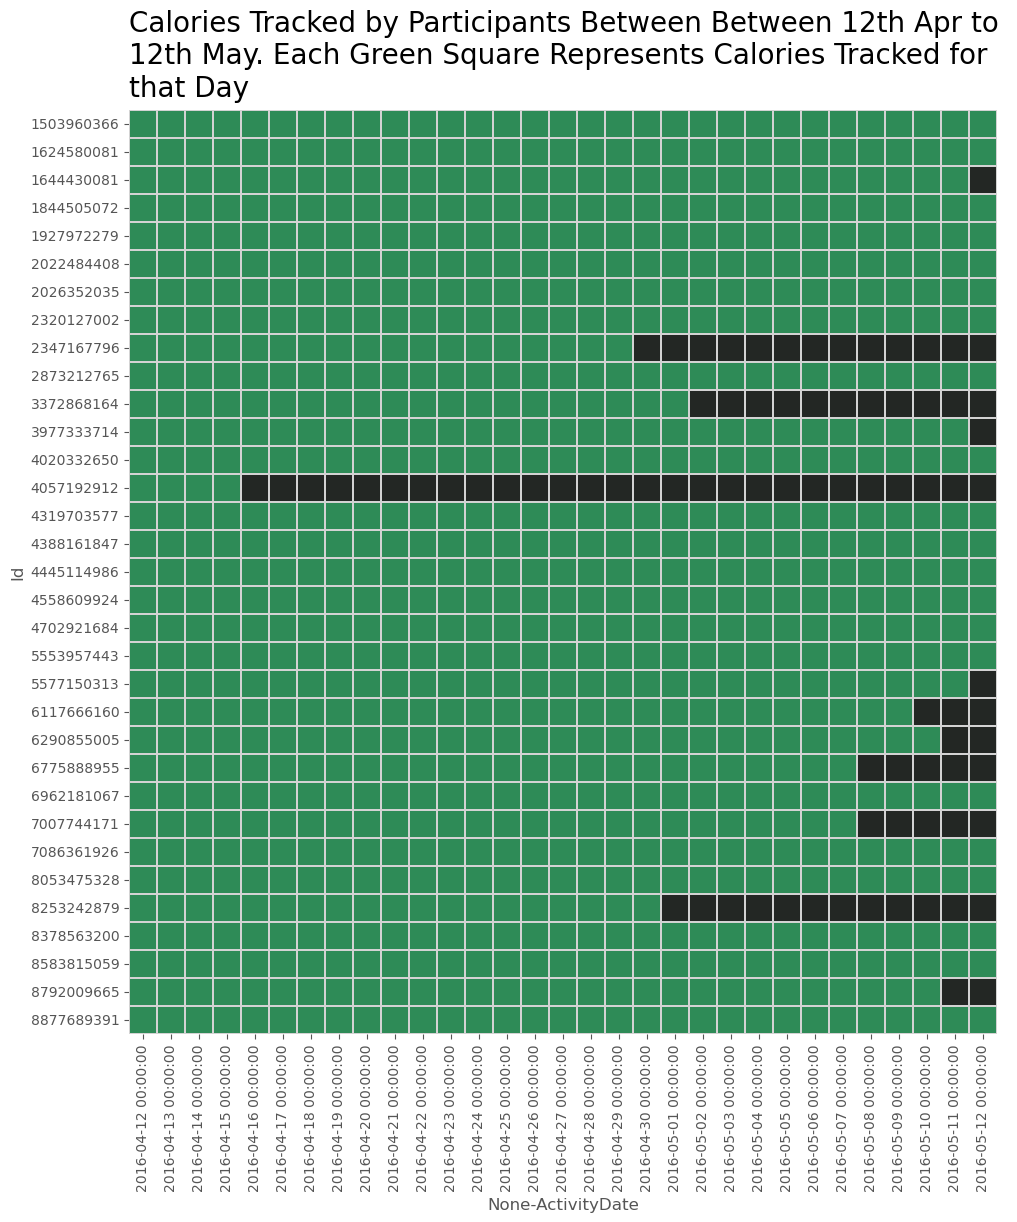

In [675]:
plt.subplots(figsize=(18,12))

# Using a green sequential palette to visualise sleep. The intense green i
seagreen_palette = sns.dark_palette("seagreen")

g = sns.heatmap(calories_pivot.notna(), square=True, 
                cmap=seagreen_palette, cbar=False,  # type: ignore
                linewidths=0.1, linecolor='lightgrey',
                xticklabels=steps.columns) # type: ignore

g.axes.set_title('Calories Tracked by Participants Between Between 12th Apr to \n12th May. Each Green Square Represents Calories Tracked for \nthat Day',  # type: ignore
                 loc='left', fontsize=20, pad=10)
g.axes.set_facecolor('white') # type: ignore

##### Q13: How much calories do people expend per day? If we average everyones calorie expenditure over the dataset, shat is the average calories expended over the past 30 days?
- The number of calories expended is also quite suspicious. According to this [article][healthline], an average female expends 1,600 - 2,200 calories per day while an average male expends 2,000 - 3,000 calories per day. There are quite a number of 4,000 - 5,000 calorie figures in this dataset. Perhaps the smart devices algorithm works to overestimate calorie expenditure?

<ins>Summary of Findings</ins>
- Mean calorie expenditure is 2300 calories, median is 2100 calories


[healthline]: https://www.healthline.com/health/fitness-exercise/how-many-calories-do-i-burn-a-day#:~:text=Every%20day%2C%20you%20burn%20calories,and%20activity%20levels%20(%201%20).

In [686]:
calorie_mean_histplot = calories_pivot.mean(axis=1).to_frame()
calorie_mean_histplot.rename(columns={0:'calorie'}, inplace=True)
# calorie_mean_histplot

In [685]:
calorie_mean_histplot.describe()

,calorie
count,33.000000
mean,2282.443660
std,562.761632
min,1483.354839
25%,1916.967742
50%,2131.769231
75%,2599.620690
max,3436.580645


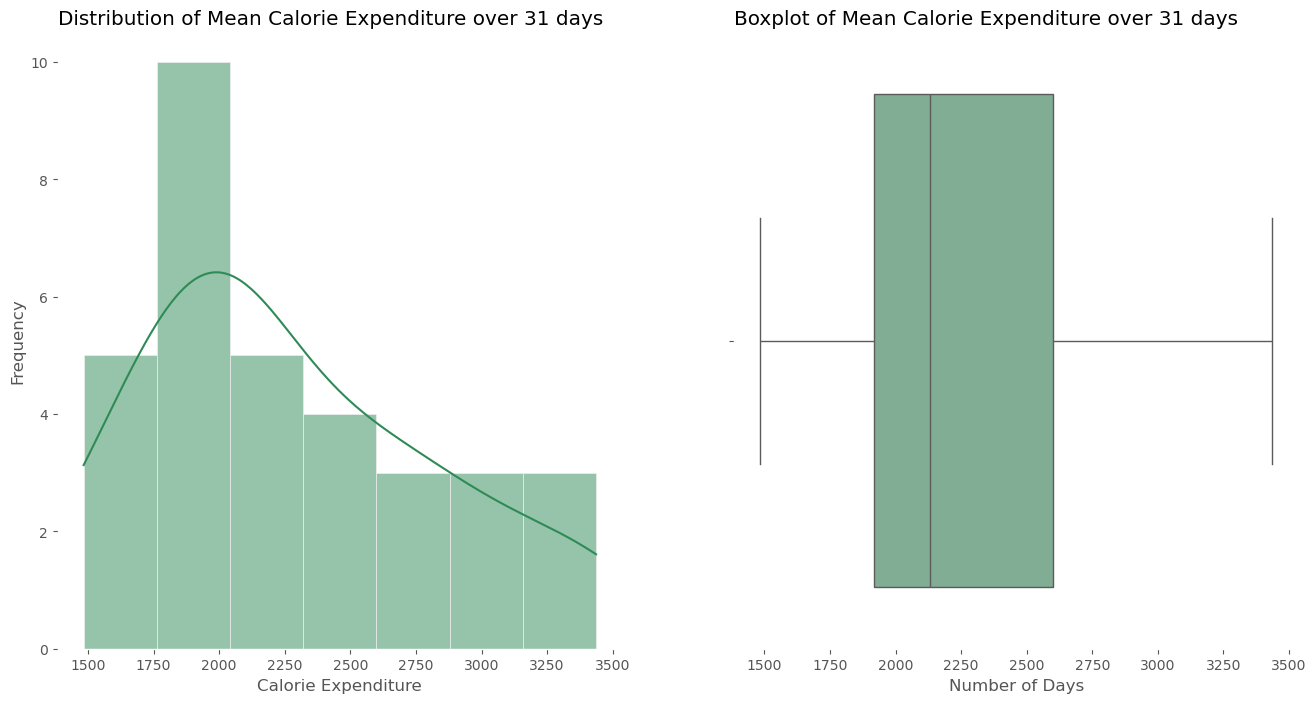

In [687]:
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=calorie_mean_histplot, x='calorie', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=calorie_mean_histplot, x='calorie', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Calorie Expenditure')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of Mean Calorie Expenditure over 31 days', loc='left')
ax[1].set_xlabel('Number of Days')
ax[1].set_title('Boxplot of Mean Calorie Expenditure over 31 days', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

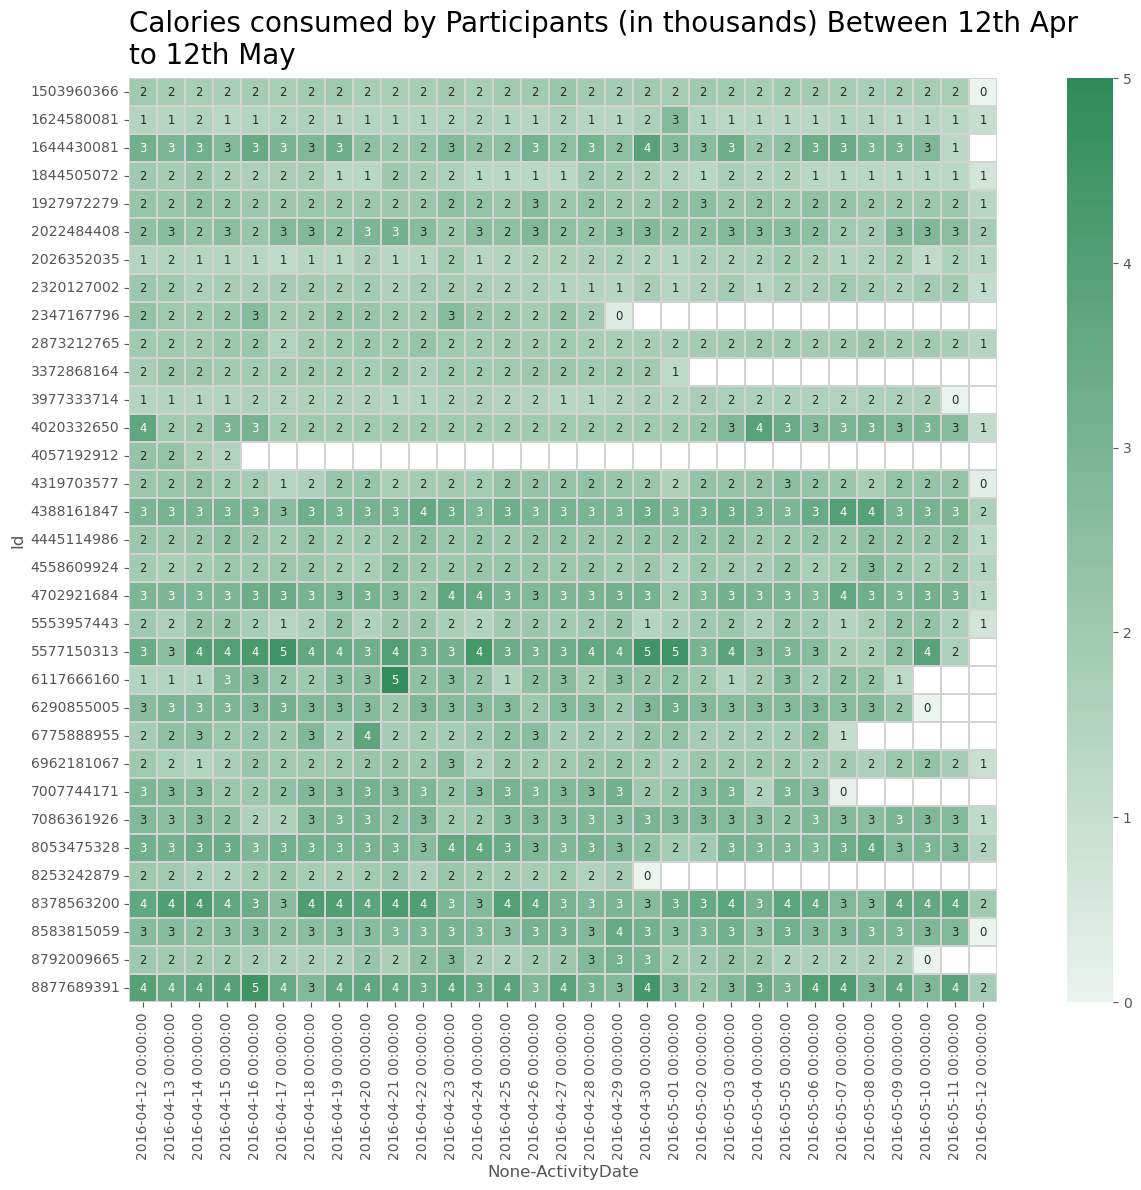

In [643]:
plt.subplots(figsize=(18,12))

# Using a green sequential palette to visualise sleep. The intense green i
seagreen_palette = sns.light_palette("seagreen", as_cmap=True)

# Creating labels for the heatmap
labels = calories_pivot.map(lambda x: f'{x/1000:.0f}')

g = sns.heatmap(calories_pivot/1000, square=True, 
                cmap=seagreen_palette, cbar=True,  # type: ignore
                vmin=0, vmax=5,
                linewidths=0.1, linecolor='lightgrey',
                annot=labels, annot_kws={'size':'small', 'alpha':1}, fmt='',
                xticklabels=steps.columns) # type: ignore

g.axes.set_title('Calories consumed by Participants (in thousands) Between 12th Apr \nto 12th May',  # type: ignore
                 loc='left', fontsize=20, pad=10)
g.axes.set_facecolor('white') # type: ignore